# Libraries and Data Information

## Installations

### Mount Google Drive

In [1]:
from google.colab import drive, files, runtime
drive.mount('/content/drive')

Mounted at /content/drive


### Check for Nvidia GPU.

In [2]:
!nvidia-smi

Thu Apr 30 05:13:39 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

### Create Virtual Environment

In [3]:
#!python -m venv /content/drive/My Drive/my_env  # Store in your Drive

### Activate Environment

In [4]:
!source /content/drive/My Drive/my_env/bin/activate

/bin/bash: line 1: /content/drive/My: No such file or directory


## Install Packages.

In [5]:
!pip install numpy  # Install or upgrade NumPy first
!pip install scipy==1.10.0 # Install scipy specifically version 1.10.0
!pip install scikit-learn  # Install scikit-learn
!pip install tensorflow  # Install TensorFlow
!pip install torch  # Install PyTorch

ERROR: Ignored the following yanked versions: 1.11.0, 1.14.0rc1
ERROR: Ignored the following versions that require a different python version: 1.10.0 Requires-Python <3.12,>=3.8; 1.10.0rc1 Requires-Python <3.12,>=3.8; 1.10.0rc2 Requires-Python <3.12,>=3.8; 1.10.1 Requires-Python <3.12,>=3.8; 1.6.2 Requires-Python >=3.7,<3.10; 1.6.3 Requires-Python >=3.7,<3.10; 1.7.0 Requires-Python >=3.7,<3.10; 1.7.1 Requires-Python >=3.7,<3.10; 1.7.2 Requires-Python >=3.7,<3.11; 1.7.3 Requires-Python >=3.7,<3.11; 1.8.0 Requires-Python >=3.8,<3.11; 1.8.0rc1 Requires-Python >=3.8,<3.11; 1.8.0rc2 Requires-Python >=3.8,<3.11; 1.8.0rc3 Requires-Python >=3.8,<3.11; 1.8.0rc4 Requires-Python >=3.8,<3.11; 1.8.1 Requires-Python >=3.8,<3.11; 1.9.0 Requires-Python >=3.8,<3.12; 1.9.0rc1 Requires-Python >=3.8,<3.12; 1.9.0rc2 Requires-Python >=3.8,<3.12; 1.9.0rc3 Requires-Python >=3.8,<3.12; 1.9.1 Requires-Python >=3.8,<3.12
ERROR: Could not find a version that satisfies the requirement scipy==1.10.0 (from versions:

In [6]:
!pip install numpy  # Install NumPy first
!pip install numpy.rec # Install numpy.rec specifically.
!pip install scipy==1.10.0 # Reinstall SciPy with the version you need.
#!pip install keras_spiking --upgrade # Install keras_spiking
!pip install keras_spiking # Install keras_spiking

ERROR: Could not find a version that satisfies the requirement numpy.rec (from versions: none)
ERROR: No matching distribution found for numpy.rec
ERROR: Ignored the following yanked versions: 1.11.0, 1.14.0rc1
ERROR: Ignored the following versions that require a different python version: 1.10.0 Requires-Python <3.12,>=3.8; 1.10.0rc1 Requires-Python <3.12,>=3.8; 1.10.0rc2 Requires-Python <3.12,>=3.8; 1.10.1 Requires-Python <3.12,>=3.8; 1.6.2 Requires-Python >=3.7,<3.10; 1.6.3 Requires-Python >=3.7,<3.10; 1.7.0 Requires-Python >=3.7,<3.10; 1.7.1 Requires-Python >=3.7,<3.10; 1.7.2 Requires-Python >=3.7,<3.11; 1.7.3 Requires-Python >=3.7,<3.11; 1.8.0 Requires-Python >=3.8,<3.11; 1.8.0rc1 Requires-Python >=3.8,<3.11; 1.8.0rc2 Requires-Python >=3.8,<3.11; 1.8.0rc3 Requires-Python >=3.8,<3.11; 1.8.0rc4 Requires-Python >=3.8,<3.11; 1.8.1 Requires-Python >=3.8,<3.11; 1.9.0 Requires-Python >=3.8,<3.12; 1.9.0rc1 Requires-Python >=3.8,<3.12; 1.9.0rc2 Requires-Python >=3.8,<3.12; 1.9.0rc3 Requires

## Libraries

In [7]:
#matplotlib imports
import matplotlib.pyplot as plt
import matplotlib.pyplot as scatter
import matplotlib.cm as cm
import time
import random
import io
import zipfile


from sklearn.preprocessing import MinMaxScaler, StandardScaler, MaxAbsScaler
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import mean_absolute_percentage_error

# keras/tensorflow imports
import tensorflow as tf
from tensorflow.python.keras.engine.base_layer import Layer
#from tensorflow.python.keras.layers.rnn.rnn import RNN
from keras.layers import Dense, Dropout, SimpleRNN, LSTM, GRU, Flatten, Conv1D
from keras.layers import MaxPooling1D, TimeDistributed, GlobalAveragePooling1D
from keras.models import Sequential
import keras_spiking
from keras_spiking import SpikingActivation

# warnings imports
import warnings
warnings.filterwarnings("ignore")


# torch imports
import torch
import torch.nn as nn
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"{device}" " is available.")

# Other imports
from urllib.request import urlretrieve
import collections
import numpy as np
import pandas as pd
from math import sqrt
import os
import pickle
from datetime import datetime, timedelta
from google.colab import drive

cuda is available.


# Load Data

In [8]:
data_to_load = files.upload()
list_of_dfs = []

for filename, content in data_to_load.items():
    if filename.endswith('.csv'):
        # Decode the byte content to string and then read into pandas
        df = pd.read_csv(io.StringIO(content.decode('utf-8')))
        list_of_dfs.append((filename, df)) # Store filename along with DataFrame
        print(f"Successfully loaded {filename} with shape: {df.shape}")
    elif filename.endswith('.zip'):
        print(f"Detected ZIP file: {filename}")
        try:
            # Create a BytesIO object from the content
            zip_file_object = io.BytesIO(content)
            with zipfile.ZipFile(zip_file_object, 'r') as zf:
                # Iterate through all files in the zip archive
                for member in zf.namelist():
                    if member.endswith('.csv'):
                        print(f"  Extracting and loading CSV from zip: {member}")
                        with zf.open(member) as csv_file:
                            # Read CSV content from the extracted file
                            csv_content = csv_file.read().decode('utf-8')
                            df = pd.read_csv(io.StringIO(csv_content))
                            list_of_dfs.append((member, df))
                            print(f"  Successfully loaded {member} with shape: {df.shape}")
                    else:
                        print(f"  Skipping non-CSV file within zip: {member}")
        except zipfile.BadZipFile:
            print(f"Error: {filename} is not a valid ZIP file.")
        except Exception as e:
            print(f"An error occurred while processing {filename}: {e}")
    else:
        print(f"Skipping non-CSV and non-ZIP file: {filename}")

Saving realKnownCause.zip to realKnownCause.zip
Detected ZIP file: realKnownCause.zip
  Extracting and loading CSV from zip: realKnownCause/ambient_temperature_system_failure.csv
  Successfully loaded realKnownCause/ambient_temperature_system_failure.csv with shape: (7267, 2)
  Extracting and loading CSV from zip: realKnownCause/cpu_utilization_asg_misconfiguration.csv
  Successfully loaded realKnownCause/cpu_utilization_asg_misconfiguration.csv with shape: (18050, 2)
  Extracting and loading CSV from zip: realKnownCause/ec2_request_latency_system_failure.csv
  Successfully loaded realKnownCause/ec2_request_latency_system_failure.csv with shape: (4032, 2)
  Extracting and loading CSV from zip: realKnownCause/machine_temperature_system_failure.csv
  Successfully loaded realKnownCause/machine_temperature_system_failure.csv with shape: (22695, 2)
  Extracting and loading CSV from zip: realKnownCause/nyc_taxi.csv
  Successfully loaded realKnownCause/nyc_taxi.csv with shape: (10320, 2)
  Ex

# Read and Check Data

## Preprocessing stage.

In [9]:
all_loaded_csv_filenames = [item[0] for item in list_of_dfs]
filename = all_loaded_csv_filenames[random.randint(0, len(all_loaded_csv_filenames)-1)]
print(f"Selected filename: {filename}")

Selected filename: realKnownCause/machine_temperature_system_failure.csv


In [10]:
# Retrieve the DataFrame corresponding to the selected filename
df_entire = next(df for f, df in list_of_dfs if f == filename)
df_entire.head()

,timestamp,value
0,2013-12-02 21:15:00,73.967322
1,2013-12-02 21:20:00,74.935882
2,2013-12-02 21:25:00,76.124162
3,2013-12-02 21:30:00,78.140707
4,2013-12-02 21:35:00,79.329836


In [11]:
df_entire.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22695 entries, 0 to 22694
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   timestamp  22695 non-null  object 
 1   value      22695 non-null  float64
dtypes: float64(1), object(1)
memory usage: 354.7+ KB


## Other Pre-Processing Information

In [12]:
# We must convert the Datetime column to Datetime format
df_entire['timestamp'] = pd.to_datetime(df_entire['timestamp'])

# We index the Datetime column after transformation
df_entire.set_index('timestamp', inplace=True)
df_entire.head()

,value
timestamp,
2013-12-02 21:15:00,73.967322
2013-12-02 21:20:00,74.935882
2013-12-02 21:25:00,76.124162
2013-12-02 21:30:00,78.140707
2013-12-02 21:35:00,79.329836


In [13]:
# checking missing data
df_entire.isna().sum()

,0
value,0


In [14]:
# Let's look at the years in the data set
months = df_entire.index.month.unique()
months

Index([12, 1, 2], dtype='int32', name='timestamp')

## Plot BA Actual Values based on Trends and Seasonality.

In [15]:
def plot_nabs(select_df, start, end, seasonality, title_name, feature):
    plt.figure(figsize=(16, 16))
    plt.plot(select_df[start:end], label=feature)
    plt.locator_params(axis='x', nbins=10)
    plt.locator_params(axis='y', nbins=10)
    plt.rc('xtick', labelsize=20)
    plt.rc('ytick', labelsize=20)
    plt.ylabel(feature, fontsize = 20)
    plt.xlabel("Date", fontsize = 20)
    plt.title("{0} ({1})".format(title_name, seasonality), fontsize = 20)
    plt.show()

### Trend Plot

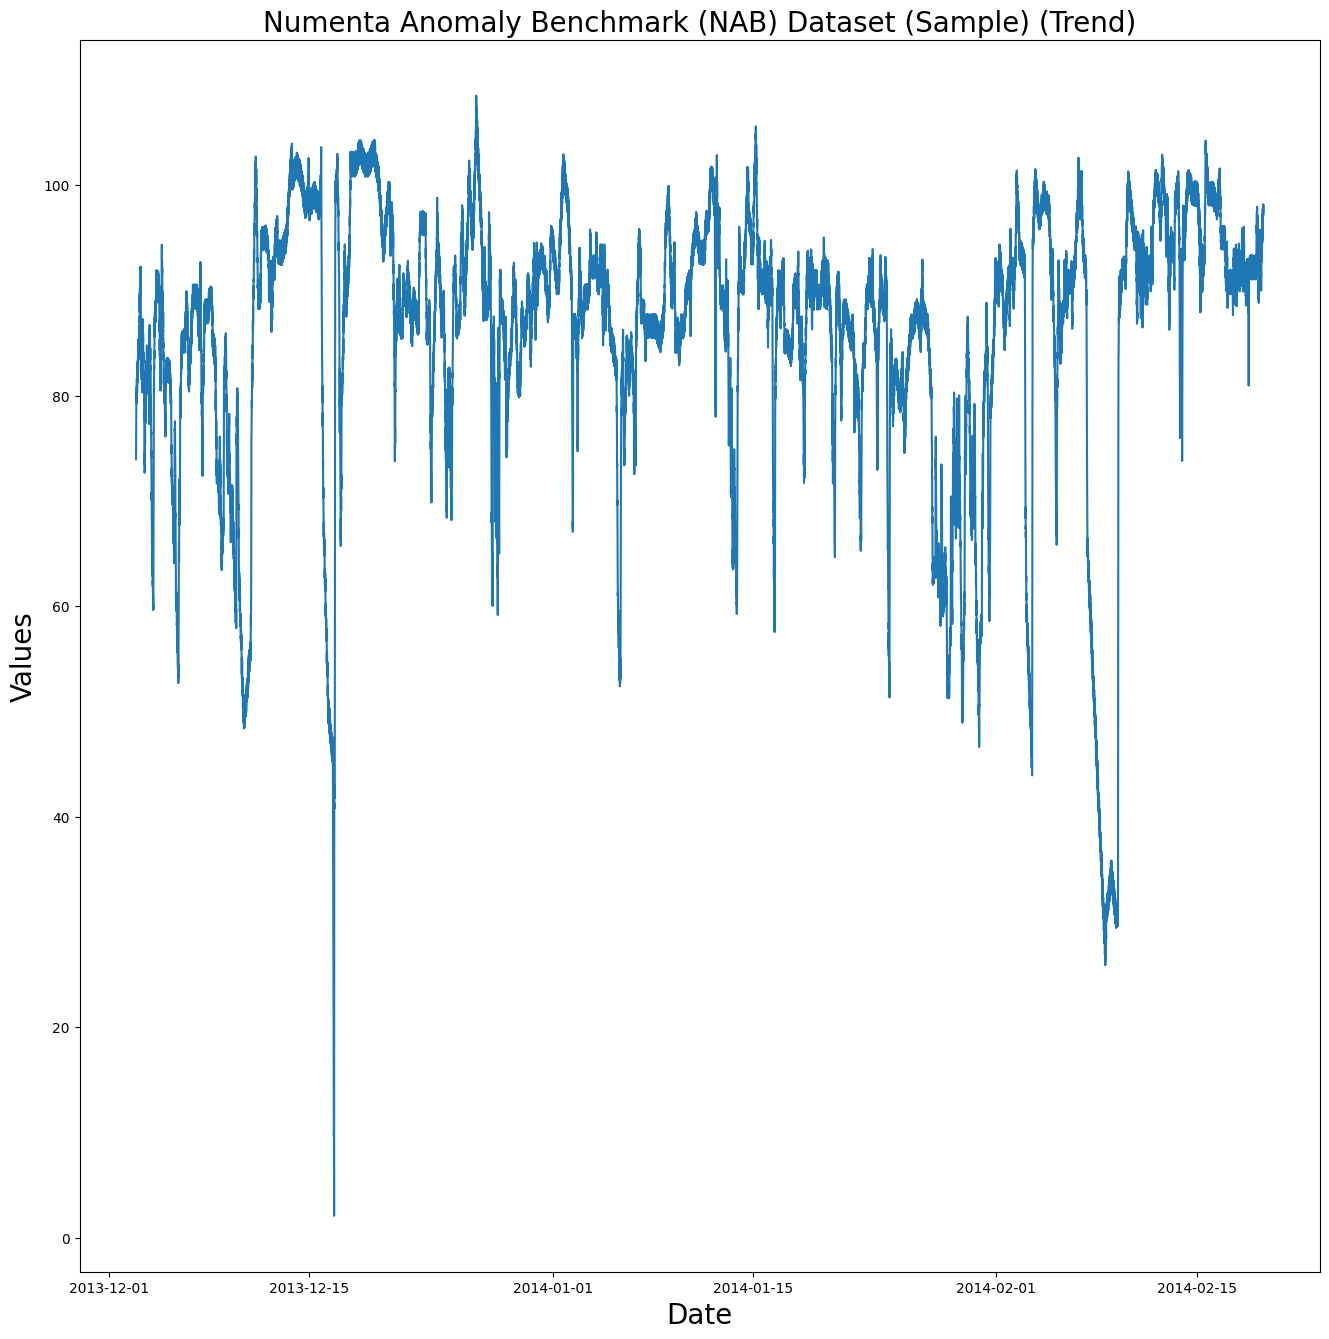

In [16]:
title_name = 'Numenta Anomaly Benchmark (NAB) Dataset (Sample)'
plot_nabs(df_entire, 0, df_entire.shape[0]-1, "Trend", title_name,
                 'Values')

### Monthly Plots (Seasonality)

In [17]:
#monthly_df = df_entire.query("timestamp >= '2014-01-01' and \
#                              timestamp <= '2014-02-01'")
#monthly_df

In [18]:
#plot_nabs(monthly_df, 0, monthly_df.shape[0]-1, "Seasonality (Monthly).",
#                 'BA Solar Actuals for Particular Site May 2017', 'BA Actual')

# Normalization Process

In [19]:
def get_scaler(scaler):
    scalers = {
        "minmax": MinMaxScaler,
        "standard": StandardScaler,
        "maxabs": MaxAbsScaler,
        "robust": RobustScaler,
    }
    return scalers.get(scaler.lower())()

def normalize_data(df):
    scaler_type = 'minmax'
    #scaler_type = input("Enter a scaler type (minmax,standard, maxabs, robust): ")
    if (scaler_type != 'minmax') and (scaler_type != 'standard') and (scaler_type != 'maxabs') and (scaler_type != 'robust'):
      runtime.unassign()

    scaler = get_scaler(scaler_type)
    normalized_data_BA_Actual = scaler.fit_transform(df['value'].
                                               values.reshape(-1,1))
    df['value_Norm'] = normalized_data_BA_Actual
    return df, scaler

df_norm, scaler = normalize_data(df_entire)
#df_norm_mon, scaler = normalize_data(monthly_df)

In [20]:
df_norm

,value,value_Norm
timestamp,,
2013-12-02 21:15:00,73.967322,0.675424
2013-12-02 21:20:00,74.935882,0.684525
2013-12-02 21:25:00,76.124162,0.695691
2013-12-02 21:30:00,78.140707,0.714638
2013-12-02 21:35:00,79.329836,0.725812
...,...,...
2014-02-19 15:05:00,98.185415,0.902983
2014-02-19 15:10:00,97.804168,0.899401
2014-02-19 15:15:00,97.135468,0.893117


## Plot BA Actual Normalized based on Trend and Seasonality.

Now after normalization we can observe that the data range on y-axis is 0.0 - 1.0.

### Trend Plot

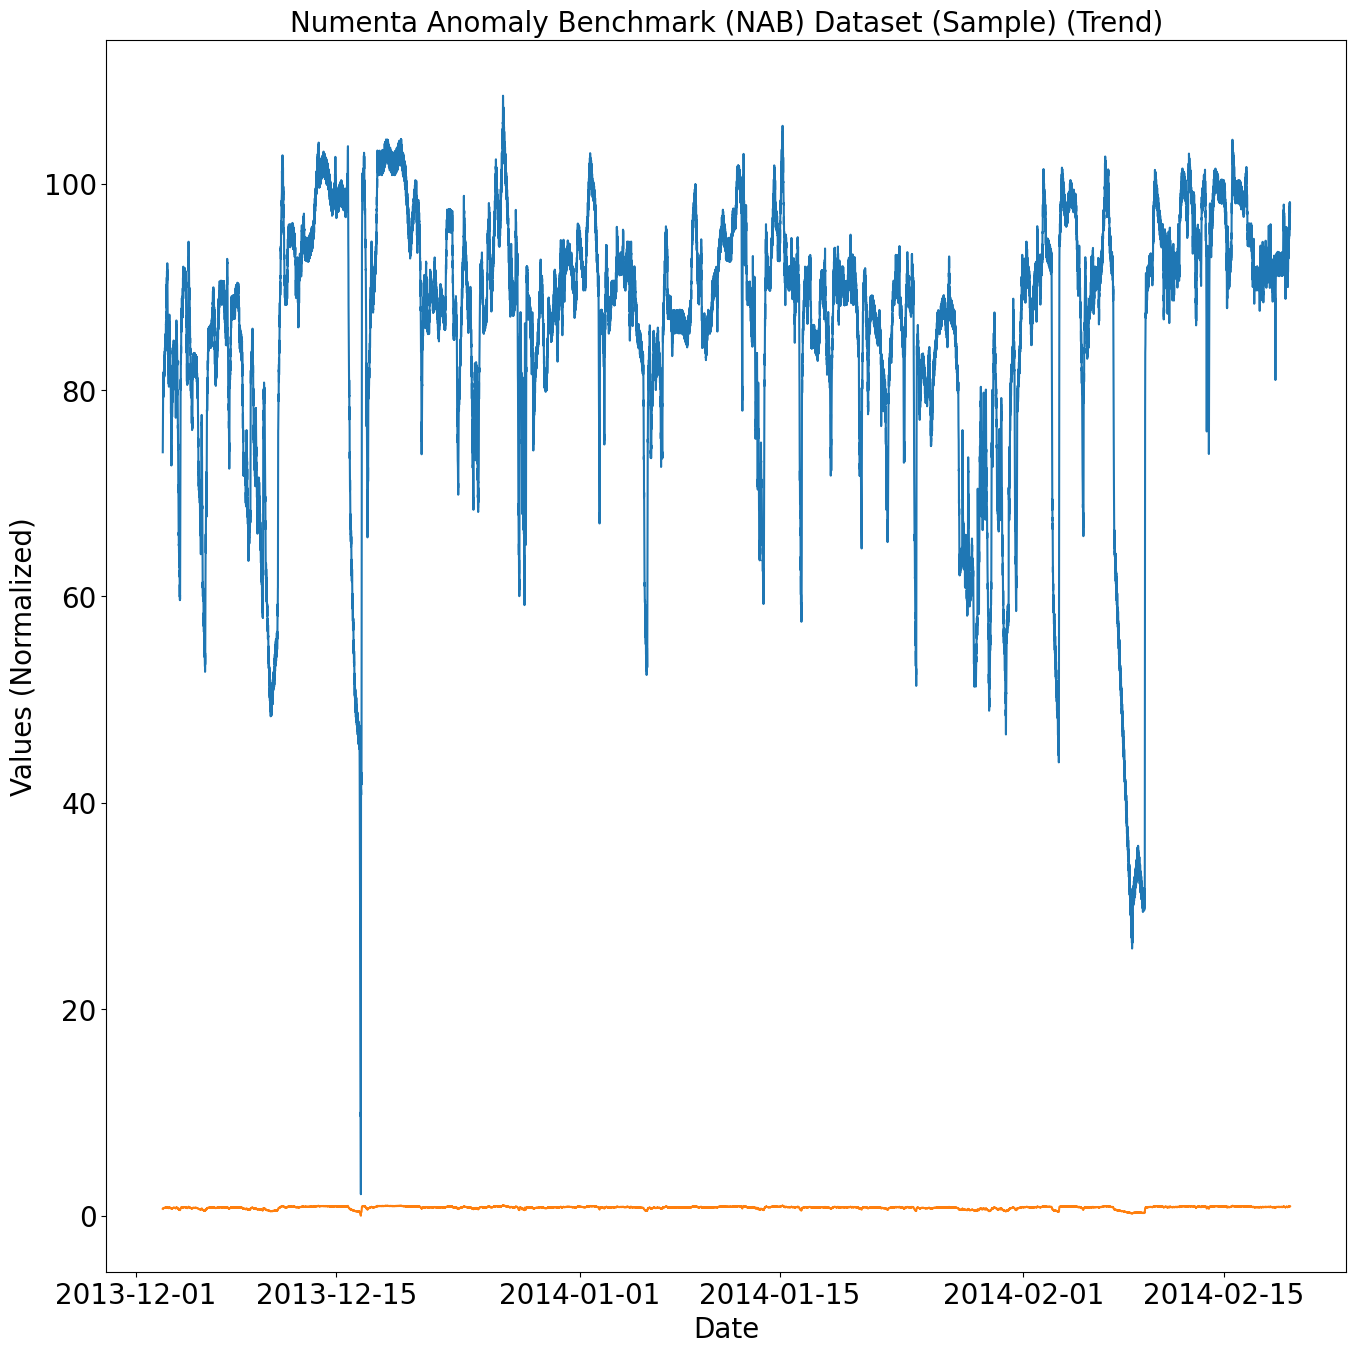

In [21]:
plot_nabs(df_norm, 0, df_norm.shape[0]-1, "Trend", title_name,
                 'Values (Normalized)')

### Monthly Plots (Seasonality)

In [22]:
#plot_nabs(df_norm_mon, 0, df_norm_mon.shape[0]-1, "Monthly",
#                  title_name, 'Values (Normalized)')

# Let's observe train and test data on the graph

## Split into Train/Test Data.

In [23]:
test_size = 0.2 # Set Split rate to 3:1 (80 % Training 20 % Test).
split_pos = int(df_entire.shape[0]*(1 - test_size))
df_entire = df_entire.reset_index()
df_entire

,timestamp,value,value_Norm
0,2013-12-02 21:15:00,73.967322,0.675424
1,2013-12-02 21:20:00,74.935882,0.684525
2,2013-12-02 21:25:00,76.124162,0.695691
3,2013-12-02 21:30:00,78.140707,0.714638
4,2013-12-02 21:35:00,79.329836,0.725812
...,...,...,...
22690,2014-02-19 15:05:00,98.185415,0.902983
22691,2014-02-19 15:10:00,97.804168,0.899401
22692,2014-02-19 15:15:00,97.135468,0.893117
22693,2014-02-19 15:20:00,98.056852,0.901775


In [24]:
# 2019-02-06 will be the date seperation. Dates past this will be the test set.
split_date = str(df_entire.timestamp[split_pos])
#split_date = split_date[:10]
#DOM_train = df_norm.loc[df_norm.index <= split_date].copy()
DOM_train = df_entire.loc[df_norm.index <= split_date].copy()
#DOM_test = df_norm.loc[df_norm.index > split_date].copy()
DOM_test = df_entire.loc[df_norm.index > split_date].copy()
split_date

'2014-02-03 21:15:00'

## Plot Train/Test Split Graphs.

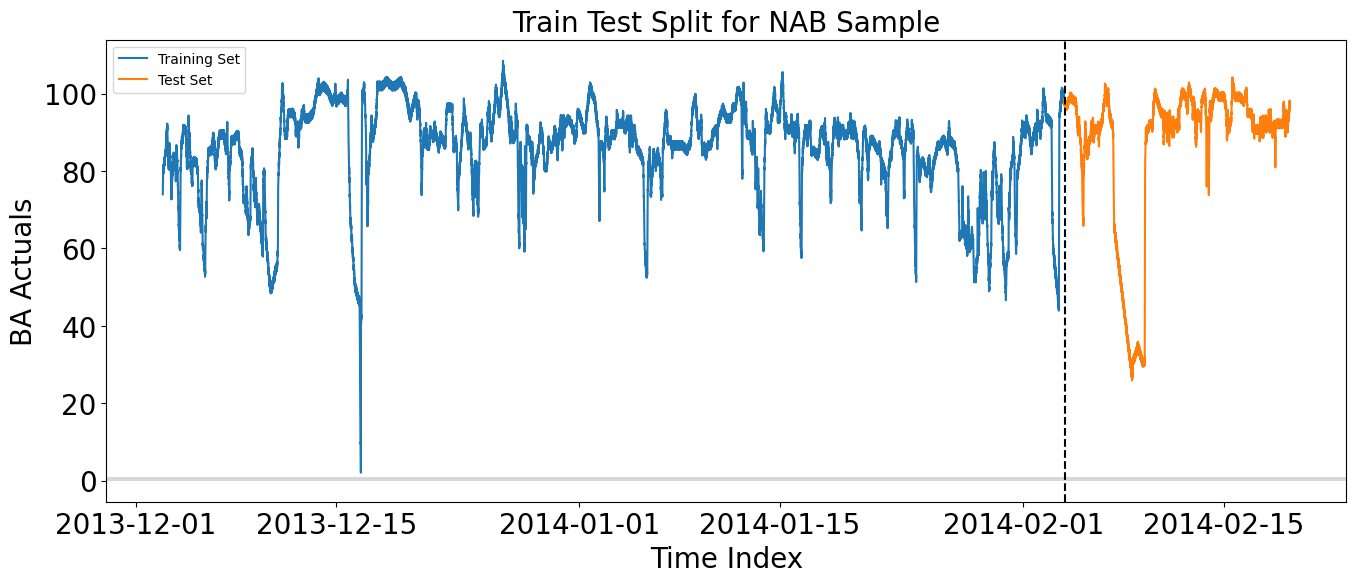

In [25]:
# Monthly Mean Total Sunspot Number Train Test Split
plt.figure(figsize=(16,6))
plt.plot(DOM_train['timestamp'], DOM_train['value'],
         label='Training Set')
plt.plot(DOM_test['timestamp'], DOM_test['value'],
         label='Testing Set')
plt.axvline(x = df_entire.timestamp[split_pos], color='black', ls='--')
plt.legend(['Training Set', 'Test Set'])
plt.axhspan(0, 1, facecolor='gray', alpha=0.3)
plt.xlabel("Time Index", fontsize = 20)
plt.ylabel("BA Actuals", fontsize = 20)
plt.title("Train Test Split for NAB Sample", fontsize = 20)
plt.show()

In [26]:
# We index the Datetime column after transformation
df_entire.set_index('timestamp', inplace=True)
df_entire.head()

,value,value_Norm
timestamp,,
2013-12-02 21:15:00,73.967322,0.675424
2013-12-02 21:20:00,74.935882,0.684525
2013-12-02 21:25:00,76.124162,0.695691
2013-12-02 21:30:00,78.140707,0.714638
2013-12-02 21:35:00,79.329836,0.725812


In [27]:
df_entire1 = df_entire.drop(columns = ['value_Norm'])
df_entire1

,value
timestamp,
2013-12-02 21:15:00,73.967322
2013-12-02 21:20:00,74.935882
2013-12-02 21:25:00,76.124162
2013-12-02 21:30:00,78.140707
2013-12-02 21:35:00,79.329836
...,...
2014-02-19 15:05:00,98.185415
2014-02-19 15:10:00,97.804168
2014-02-19 15:15:00,97.135468


In [28]:
df_entire2 = df_entire.drop(columns = ['value'])
df_entire2

,value_Norm
timestamp,
2013-12-02 21:15:00,0.675424
2013-12-02 21:20:00,0.684525
2013-12-02 21:25:00,0.695691
2013-12-02 21:30:00,0.714638
2013-12-02 21:35:00,0.725812
...,...
2014-02-19 15:05:00,0.902983
2014-02-19 15:10:00,0.899401
2014-02-19 15:15:00,0.893117


# Prepare Data for Training the Models.

* With the following function block, let's set the data set as training and test data set in a model appropriate way

In [29]:
def load_data(data, seq_len, feature_column):
    X_train = []
    y_train = []

    for i in range(seq_len, len(data)):
        X_train.append(data[feature_column].iloc[i-seq_len : i])
        y_train.append(data[feature_column].iloc[i])

    # last days are going to be used in test
    X_test = X_train[split_pos:]
    y_test = y_train[split_pos:]

    # first  days are going to be used in training
    X_train = X_train[:split_pos]
    y_train = y_train[:split_pos]

    # convert to numpy array
    X_train = np.array(X_train)
    y_train = np.array(y_train)
    X_test = np.array(X_test)
    y_test = np.array(y_test)


    # reshape data to input into RNN, LSTM, and GRU models
    X_train = np.reshape(X_train, (X_train.shape[0], seq_len, 1))
    X_test = np.reshape(X_test, (X_test.shape[0], seq_len, 1))


    return [X_train, y_train, X_test, y_test]

* **The seq_len** parameter determines how far back the model will look at historical data, helping the model to capture time dependencies in a memory-aware way.
* If "seq_len" is too large, the model can become complex and prone to overlearning.

In [30]:
feature = 'value'
#selected_df = df_entire1
selected_df = df_entire2
feature_norm = 'value_Norm'
feature_field = 'value'

In [31]:
seq_len = 20
#seq_len = 6*24*30

# Let's create train, test data
X_train, y_train, X_test, y_test = load_data(selected_df, seq_len, feature_norm)
#X_train, y_train, X_test, y_test = load_data(df_norm2, seq_len)


print('X_train.shape = ',X_train.shape)
print('y_train.shape = ', y_train.shape)
print('X_test.shape = ', X_test.shape)
print('y_test.shape = ',y_test.shape)

X_train.shape =  (18156, 20, 1)
y_train.shape =  (18156,)
X_test.shape =  (4519, 20, 1)
y_test.shape =  (4519,)


In [32]:
X_train

array([[[0.67542444],
        [0.68452524],
        [0.69569057],
        ...,
        [0.74501519],
        [0.74799724],
        [0.73381185]],

       [[0.68452524],
        [0.69569057],
        [0.71463847],
        ...,
        [0.74799724],
        [0.73381185],
        [0.74871357]],

       [[0.69569057],
        [0.71463847],
        [0.72581178],
        ...,
        [0.73381185],
        [0.74871357],
        [0.74394595]],

       ...,

       [[0.91028955],
        [0.90829654],
        [0.90174503],
        ...,
        [0.89178473],
        [0.89780377],
        [0.88697879]],

       [[0.90829654],
        [0.90174503],
        [0.90820104],
        ...,
        [0.89780377],
        [0.88697879],
        [0.89520638]],

       [[0.90174503],
        [0.90820104],
        [0.89074345],
        ...,
        [0.88697879],
        [0.89520638],
        [0.90026402]]])

In [33]:
X_test

array([[[0.90820104],
        [0.89074345],
        [0.90915004],
        ...,
        [0.89520638],
        [0.90026402],
        [0.89311055]],

       [[0.89074345],
        [0.90915004],
        [0.89630184],
        ...,
        [0.90026402],
        [0.89311055],
        [0.89119657]],

       [[0.90915004],
        [0.89630184],
        [0.89647063],
        ...,
        [0.89311055],
        [0.89119657],
        [0.89678657]],

       ...,

       [[0.87824985],
        [0.86983175],
        [0.87659729],
        ...,
        [0.89523559],
        [0.90298287],
        [0.8994006 ]],

       [[0.86983175],
        [0.87659729],
        [0.89015836],
        ...,
        [0.90298287],
        [0.8994006 ],
        [0.89311734]],

       [[0.87659729],
        [0.89015836],
        [0.87212086],
        ...,
        [0.8994006 ],
        [0.89311734],
        [0.90177487]]])

In [34]:
y_train

array([0.74871357, 0.74394595, 0.73495524, ..., 0.89520638, 0.90026402,
       0.89311055])

In [35]:
y_test

array([0.89119657, 0.89678657, 0.8820721 , ..., 0.89311734, 0.90177487,
       0.89094111])

## Essential Variables.

In [36]:
epochs = 10
batch_size = 32
loss = 'MAE'
#loss = 'MSE'
#activation = 'sigmoid'
activation = 'tanh'
#activation = 'relu'

## Training Loss vs. Epochs Plot

Plotting Accuracy and Validation Accuracy vs Epochs. Code taken from https://machinelearningmastery.com/display-deep-learning-model-training-history-in-keras/.

In [37]:
def plot_training_loss(model, model_name):
    model.history.keys()
    plt.plot(model.history['loss'])
    plt.title('Training Loss vs. Epochs for {0}'.format(model_name))
    plt.ylabel('loss')
    plt.xlabel('epoch')
    plt.show()

## Normalized Energy Consumption per Sample.
`measure_time_and_energy` is used to calculate FLOPs for LSTM, GRU, and Conv1D layers by ensuring robust access to layer input and output shapesand return the `ann_energy_per_sample` (estimated GPU energy per sample). <br>
This function is called for the `lstm_model`, `gru_model`, `cnn_model`, and `cnn_lstm_model` to compute and display their normalized energy consumption per sample, preserving all existing output. <br>

In [38]:
def measure_time_and_energy(model, X_test):
    # Define general power estimates (in Watts) - NOT specific to Colab
    # Use these values for a rough conceptual energy estimation only.
    # Adjust these based on your research or assumptions for typical hardware.
    general_cpu_power_watts = 80 # Example general CPU power under load
    general_gpu_power_watts = 65 # Example general GPU power under load
    ann_energy_per_sample = 0.0 # Initialize variable to store the return value

    # Warm-up call to ensure the model is built before any shape access
    # Using verbose=0 to suppress output during warm-up
    _ = model.predict(X_test[:1], verbose=0)

    print("Measuring inference time and estimating energy on CPU...")


    # Create a separate model instance on CPU for measurement
    with tf.device('/CPU:0'):
        cpu_model = tf.keras.models.clone_model(model)
        # A small warm-up prediction ensures the cloned model is built
        # and its weights are initialized, making layer shapes accessible.
        cpu_model.predict(X_test[:1], verbose=0)
        # Copy weights to the CPU model
        for cpu_layer, gpu_layer in zip(cpu_model.layers, model.layers):
            cpu_layer.set_weights(gpu_layer.get_weights())

        start_time_cpu = time.time()
        predictions_cpu = cpu_model.predict(X_test, verbose=0)
        end_time_cpu = time.time()
        cpu_inference_time = end_time_cpu - start_time_cpu
        print(f"Model CPU inference time: {cpu_inference_time:.4f} seconds")

        # Estimate energy consumption (Joules = Watts * Seconds)
        estimated_cpu_energy = general_cpu_power_watts * cpu_inference_time
        print(f"Estimated CPU energy consumption (using general power value): {estimated_cpu_energy:.4f} Joules")
        # Convert to microjoules
        estimated_cpu_energy_uJ = estimated_cpu_energy * 1e6

    # Measure inference time and estimate energy on GPU if available
    if tf.config.list_physical_devices('GPU'):
        print("\nMeasuring inference time and estimating energy on GPU...")
        with tf.device('/GPU:0'):
            # For GPU measurement, it's often good practice to run a small warm-up pass
            # to ensure everything is loaded and ready on the GPU.
            _ = model.predict(X_test[:10], verbose=0) # Warm-up

            start_time_gpu = time.time()
            predictions_gpu = model.predict(X_test, verbose=0)
            end_time_gpu = time.time()
            gpu_inference_time = end_time_gpu - start_time_gpu
            print(f"Estimated GPU inference time: {gpu_inference_time:.4f} seconds")

            # Estimate energy consumption (Joules = Watts * Seconds)
            estimated_gpu_energy = general_gpu_power_watts * gpu_inference_time
            # Convert to microjoules
            estimated_gpu_energy_uJ = estimated_gpu_energy * 1e6
            print(f"Estimated GPU energy consumption (using general power value): {estimated_gpu_energy:.4f} Joules")
            total_params = model.count_params()
            memory_energy_pJ = total_params * 100  # 100 pJ per access (example value)
            memory_energy_uJ = memory_energy_pJ / 1e6
            total_gpu_energy_uJ = estimated_gpu_energy_uJ + memory_energy_uJ
            num_samples = X_test.shape[0]
            if num_samples > 0:
                ann_energy_per_sample = estimated_gpu_energy / num_samples
            print(f"ann_energy_per_sample {ann_energy_per_sample * 1e6:.2f} \u00b5J")
            print(f"Total GPU Energy: {total_gpu_energy_uJ:.2f} uJ")

    else:
        print("\nNo GPU available in this runtime. Cannot measure GPU inference time or estimate energy.")

    # --- Manual FLOPs estimation ---
    print("\nEstimating FLOPs manually...")
    total_flops = 0
    num_samples = X_test.shape[0]

    try:
        for layer in model.layers:
            layer_name = layer.__class__.__name__

            # Skip layers with negligible FLOPs or specific SNN layers
            if layer_name in ['Dropout', 'Flatten', 'MaxPooling1D', 'Reshape',
                              'SpikingActivation', 'LIFNeuronV3', 'SpikingActivationLayer',
                              'TimeDistributed']:
                continue

            # Check if layer has input_shape and output_shape attributes
            if not hasattr(layer, 'input_shape') or not hasattr(layer, 'output_shape'):
                print(f"Warning: Layer '{layer.name}' (type: {layer_name}) does not have reliable input_shape or output_shape attributes. Skipping FLOPs calculation for this layer.")
                continue

            input_shape = layer.input_shape
            output_shape = layer.output_shape

            flops_per_sample = 0

            if layer_name == 'Dense':
                # FLOPs for a Dense layer: (2 * input_dim * output_dim) + output_dim (for bias)
                if input_shape is not None and len(input_shape) > 0 and output_shape is not None and len(output_shape) > 0:
                    input_dim = input_shape[-1]
                    output_dim = output_shape[-1]
                    if input_dim is not None and output_dim is not None:
                        flops_per_sample = (2 * input_dim * output_dim) + output_dim
                    else:
                        print(f"Warning: Skipping FLOPs for Dense layer '{layer.name}' due to None dimensions in shape.")

            elif layer_name == 'LSTM' or layer_name == 'GRU':
                # A more accurate calculation for RNNs (LSTM/GRU)
                # Based on 4 gates for LSTM, each involving multiple matrix multiplications and additions.
                # Simplified estimate: 4 * (W_i * X + W_h * h + b) operations
                if hasattr(layer, 'units') and input_shape is not None and len(input_shape) > 2:
                    units = layer.units # Access units attribute
                    input_dim = input_shape[-1] # Number of features in each timestep
                    # Sequence length is the second dimension of input_shape for RNNs (batch, timesteps, features)
                    seq_len_layer = input_shape[1] if input_shape[1] is not None else X_test.shape[1]

                    if input_dim is not None and units is not None:
                        # Each gate: (input_dim * units) for input weight matrix + (units * units) for recurrent weight matrix + units for bias
                        # Total per gate: 2 * input_dim * units (weights) + 2 * units * units (recurrent weights) + 2 * units (biases and activations)
                        # Multiply by 4 for 4 gates (input, forget, cell, output) for LSTM or 3 for GRU (common approximation is 4)
                        flops_per_timestep = 4 * ( (2 * input_dim * units) + (2 * units * units) + (2 * units) ) # MAC ops + additions for weights and recurrent
                        flops_per_sample = flops_per_timestep * seq_len_layer
                    else:
                        print(f"Warning: Skipping FLOPs for RNN layer '{layer.name}' due to None dimensions in shape.")

            elif layer_name == 'Conv1D':
                # FLOPs for Conv1D: (kernel_size * in_channels * out_channels * 2 * output_length) + (out_channels * output_length for bias)
                if hasattr(layer, 'kernel_size') and input_shape is not None and len(input_shape) > 2 and output_shape is not None and len(output_shape) > 2:
                    kernel_size = layer.kernel_size[0]
                    in_channels = input_shape[-1]
                    out_channels = output_shape[-1]
                    # Output length depends on padding and stride; take from output_shape
                    output_length = output_shape[1] if output_shape[1] is not None else X_test.shape[1] # Default to X_test's seq_len if not specified

                    if kernel_size is not None and in_channels is not None and out_channels is not None and output_length is not None:
                        flops_per_sample = (kernel_size * in_channels * out_channels * 2 * output_length) + (out_channels * output_length)
                    else:
                        print(f"Warning: Skipping FLOPs for Conv1D layer {layer.name}' due to None dimensions in shape.")

            total_flops += (flops_per_sample * num_samples) # Multiply by total samples

        print(f"Estimated Total FLOPs (manual): {total_flops}")

    except Exception as e:
        print(f"Could not estimate FLOPs manually: {e}")

    return ann_energy_per_sample

## Calculate Energy in Joules from `nvidia-smi` Output

Since `nvidia-smi` reports instantaneous power in Watts, to get energy in Joules over a period, you would measure the power at certain intervals and sum up (Power × Time Interval) for each interval. For simplicity, if we assume the power draw is constant over a 1-second interval, then the Joules consumed in that second is numerically equal to the Watts drawn.

Let's run `nvidia-smi` multiple times, capture the power draw, and calculate the total energy in Joules over a short period.

In [39]:
import time
import subprocess

# Number of seconds to monitor
monitoring_duration = 5
sampling_interval = 1 # seconds

total_energy_joules = 0
print(f"Monitoring GPU power usage for {monitoring_duration} seconds and calculating total energy...")

for i in range(monitoring_duration):
    # Run nvidia-smi command to get power draw
    cmd = "nvidia-smi --query-gpu=power.draw --format=csv,noheader,nounits"
    result = subprocess.run(cmd, shell=True, capture_output=True, text=True)

    if result.returncode == 0:
        try:
            current_power_watts = float(result.stdout.strip())
            # Energy = Power * Time (assuming constant power over the sampling_interval)
            energy_this_interval = current_power_watts * sampling_interval
            total_energy_joules += energy_this_interval
            print(f"Second {i+1}: Power = {current_power_watts:.2f} W, Energy this interval = {energy_this_interval:.2f} J")
        except ValueError:
            print(f"Could not parse power output: {result.stdout.strip()}")
    else:
        print(f"Error running nvidia-smi: {result.stderr.strip()}")

    time.sleep(sampling_interval)

print(f"\nTotal estimated energy consumed over {monitoring_duration} seconds: {total_energy_joules:.2f} Joules")
print("Note: This is an approximation. For precise energy measurement, specialized hardware or more advanced tools are needed.")

Monitoring GPU power usage for 5 seconds and calculating total energy...
Second 1: Power = 9.84 W, Energy this interval = 9.84 J
Second 2: Power = 9.84 W, Energy this interval = 9.84 J
Second 3: Power = 10.04 W, Energy this interval = 10.04 J
Second 4: Power = 9.84 W, Energy this interval = 9.84 J
Second 5: Power = 10.04 W, Energy this interval = 10.04 J

Total estimated energy consumed over 5 seconds: 49.60 Joules
Note: This is an approximation. For precise energy measurement, specialized hardware or more advanced tools are needed.


In [40]:
import time

print('Monitoring GPU power usage for 10 seconds (no load expected):')
for _ in range(10):
    !nvidia-smi --query-gpu=power.draw --format=csv,noheader,nounits
    time.sleep(1)


Monitoring GPU power usage for 10 seconds (no load expected):
10.43
10.14
10.83
10.14
10.04
9.84
10.14
9.84
9.94
10.14


# LSTM model

## Create LSTM Model.

In [41]:
lstm_model = Sequential()

lstm_model.add(LSTM(8, activation=activation, return_sequences=False,
                   input_shape=(40,1)))
lstm_model.add(Dropout(0.5)) # Added to prevent overfitting

lstm_model.add(Dense(1))

lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 8)              │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 329 (1.29 KB)

 Trainable params: 329 (1.29 KB)

 Non-trainable params: 0 (0.00 B)

## Training LSTM Model.

Epoch 1/10
568/568 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - loss: 0.2285
Epoch 2/10
568/568 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0953
Epoch 3/10
568/568 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0386
Epoch 4/10
568/568 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.0279
Epoch 5/10
568/568 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0262
Epoch 6/10
568/568 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0257
Epoch 7/10
568/568 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0253
Epoch 8/10
568/568 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.0252
Epoch 9/10
568/568 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0251
Epoch 10/10
568/568 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0246


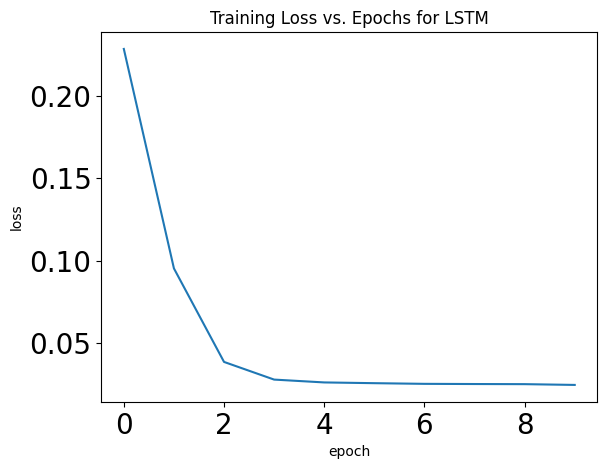

In [42]:
#lstm_model.compile(optimizer="adam",loss=loss)
# Compiled using
lstm_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                   loss=loss)
lstm_model_epochs = lstm_model.fit(X_train, y_train, epochs=epochs,
                           batch_size=batch_size)
plot_training_loss(lstm_model_epochs, "LSTM")

## Evaluate LSTM Model using MAE, RMSE, and R2.

In [43]:
print("RNN Predictions for Training Set")
lstm_predictions_train = lstm_model.predict(X_train)
print("RNN Predictions for Testing Set")
lstm_predictions_test = lstm_model.predict(X_test)
lstm_mae = mean_absolute_error(y_test,lstm_predictions_test)
print("MAE of RNN model = ",lstm_mae)
lstm_rmse =  mean_squared_error(y_test, lstm_predictions_test) ** 0.5
print("RMSE of RNN model = ", lstm_rmse)
#rnn_r2_score = r2_score(y_test,rnn_predictions_test)
#print("R2 Score of RNN model = ",rnn_r2_score)
lstm_mape_score = 100*mean_absolute_percentage_error(y_test,
                                                    lstm_predictions_test)
print("MAPE Score of RNN model = {0} %".format(lstm_mape_score))

RNN Predictions for Training Set
568/568 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
RNN Predictions for Testing Set
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
MAE of RNN model =  0.021175808270508613
RMSE of RNN model =  0.029570147503527794
MAPE Score of RNN model = 4.204002081499211 %


## Reverse Transform Scaler to Convert to Real Values.

In [44]:
y_train_inverse = scaler.inverse_transform(y_train.reshape(-1, 1))
lstm_predictions_inv_train = scaler.inverse_transform(lstm_predictions_train)

y_test_inverse = scaler.inverse_transform(y_test.reshape(-1, 1))
lstm_predictions_inv_test = scaler.inverse_transform(lstm_predictions_test)

# Get values after inverse transformation
y_train_inverse = y_train_inverse.flatten()
lstm_predictions_inv_train = lstm_predictions_inv_train.flatten()

y_test_inverse = y_test_inverse.flatten()
lstm_predictions_inv_test = lstm_predictions_inv_test.flatten()

## Show Actual and Predicted y values as Dataframes.

### With Training Dates.

In [45]:
first_6169_index_dates = df_entire.index[:X_train.shape[0]]
results_LSTM_train = pd.DataFrame({"Date": first_6169_index_dates,
                                  'Actual': y_train_inverse,
                                  'Predicted': lstm_predictions_inv_train})
results_LSTM_train

,Date,Actual,Predicted
0,2013-12-02 21:15:00,81.767178,81.432030
1,2013-12-02 21:20:00,81.259781,81.557961
2,2013-12-02 21:25:00,80.302937,81.662094
3,2013-12-02 21:30:00,81.114590,81.625061
4,2013-12-02 21:35:00,81.748109,81.572540
...,...,...,...
18151,2014-02-03 20:50:00,97.634226,95.862679
18152,2014-02-03 20:55:00,96.482168,95.807289
18153,2014-02-03 21:00:00,97.357795,95.641159
18154,2014-02-03 21:05:00,97.896059,95.505997


### With Testing Dates.

In [46]:
last_6169_index_dates = df_entire.index[-X_test.shape[0]:]
results_LSTM_test = pd.DataFrame({"Date":last_6169_index_dates,
                                 'Actual': y_test_inverse,
                                 'Predicted': lstm_predictions_inv_test})
results_LSTM_test

,Date,Actual,Predicted
0,2014-02-03 22:55:00,96.931048,95.458549
1,2014-02-03 23:00:00,97.525968,95.404305
2,2014-02-03 23:05:00,95.959969,95.431458
3,2014-02-03 23:10:00,96.169317,95.291054
4,2014-02-03 23:15:00,96.886848,95.109787
...,...,...,...
4514,2014-02-19 15:05:00,98.185415,95.977928
4515,2014-02-19 15:10:00,97.804168,96.131790
4516,2014-02-19 15:15:00,97.135468,96.238243
4517,2014-02-19 15:20:00,98.056852,96.215157


## Plotting Predictions for Monthly Mean Sunspot Number made by LSTM Model.

### Only Testing Data.

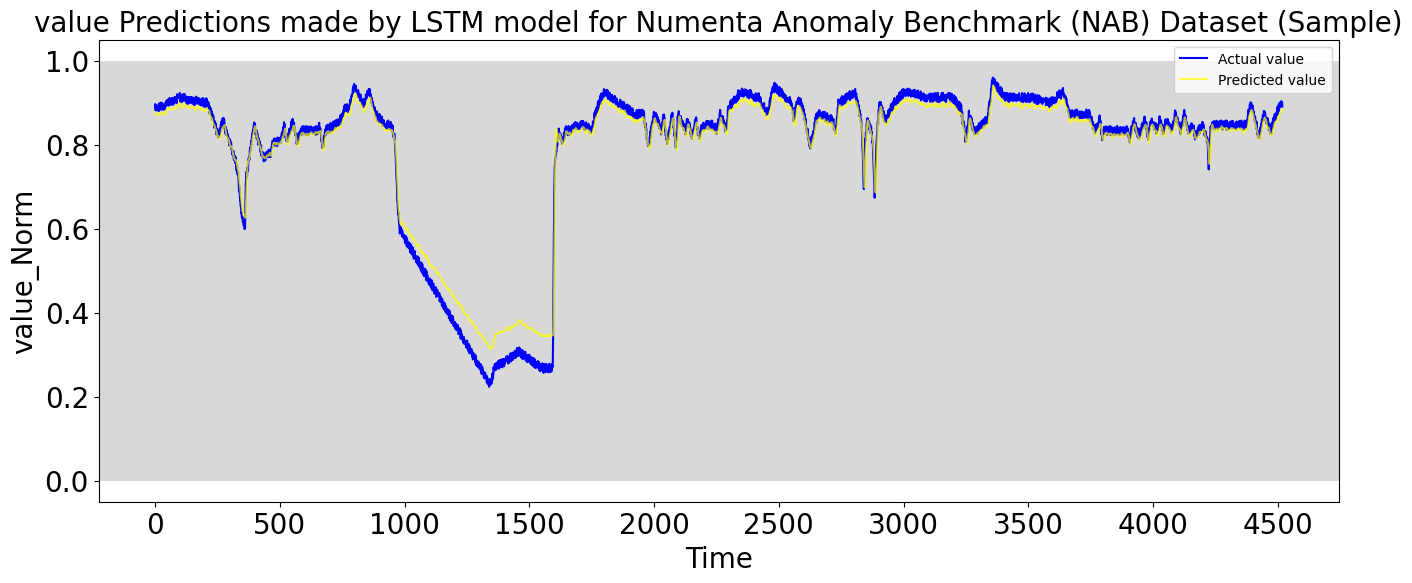

In [47]:
plt.figure(figsize=(16,6))
plt.plot(y_test, color='blue',label='Actual {0}'.format(feature))
plt.plot(lstm_predictions_test, alpha=0.7, color='yellow',
         label='Predicted {0}'.format(feature))
plt.axhspan(0, 1, facecolor='gray', alpha=0.3)
plt.title("{0} Predictions made by LSTM model for {1}".
          format(feature, title_name), fontsize = 20)
plt.rc('xtick', labelsize=20)
plt.rc('ytick', labelsize=20)
plt.locator_params(axis='x', nbins=10)
plt.locator_params(axis='y', nbins=10)
plt.xlabel('Time', fontsize = 20)
plt.ylabel(feature_norm, fontsize = 20)
plt.legend()
plt.show()

### Training and Testing Data combined.

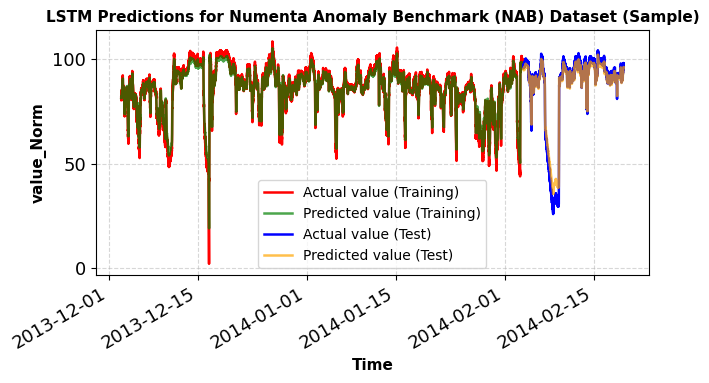

In [48]:
# 🔹 Create figure sized for IEEE 2-column layout
fig_LSTM = plt.figure(figsize=(6.5, 3.5))  # 6.5in width fits one column in IEEE

# 🔹 Plot training data
plt.plot(results_LSTM_train['Date'], results_LSTM_train['Actual'], color='red',
         label=f'Actual {feature} (Training)', linewidth=1.8)
plt.plot(results_LSTM_train['Date'], results_LSTM_train['Predicted'], color='green',
         label=f'Predicted {feature} (Training)', alpha=0.7, linewidth=1.8)

# 🔹 Plot test data
plt.plot(results_LSTM_test['Date'], results_LSTM_test['Actual'], color='blue',
         label=f'Actual {feature} (Test)', linewidth=1.8)
plt.plot(results_LSTM_test['Date'], results_LSTM_test['Predicted'], color='orange',
         label=f'Predicted {feature} (Test)', alpha=0.7, linewidth=1.8)

# 🔹 Formatting
plt.title(f'LSTM Predictions for {title_name}', fontsize=11, fontweight='bold')
plt.xlabel('Time', fontsize=11,fontweight='bold')
plt.ylabel(feature_norm, fontsize=11,fontweight='bold')
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.legend(fontsize=10, loc='best')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
fig_LSTM.autofmt_xdate()    # Auto-fix overlapping date labels
# 🔹 Export for Appendix
plt.show()

## Combine Actual and Predicted Results for Train and Test Cases for LSTM.

In [49]:
results_LSTM = [results_LSTM_train, results_LSTM_test]
results_LSTM = pd.concat(results_LSTM)
display(results_LSTM)

,Date,Actual,Predicted
0,2013-12-02 21:15:00,81.767178,81.432030
1,2013-12-02 21:20:00,81.259781,81.557961
2,2013-12-02 21:25:00,80.302937,81.662094
3,2013-12-02 21:30:00,81.114590,81.625061
4,2013-12-02 21:35:00,81.748109,81.572540
...,...,...,...
4514,2014-02-19 15:05:00,98.185415,95.977928
4515,2014-02-19 15:10:00,97.804168,96.131790
4516,2014-02-19 15:15:00,97.135468,96.238243
4517,2014-02-19 15:20:00,98.056852,96.215157


## Plotting Residuals for Actual and Predicted Results for LSTM.

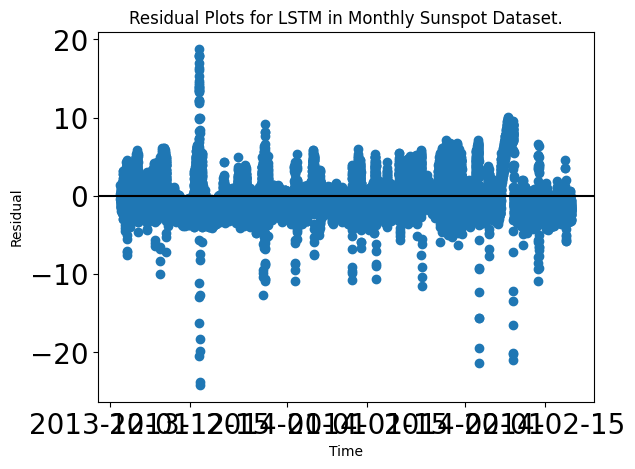

In [50]:
actual_arr_LSTM = np.array(results_LSTM['Actual'])
predicted_arr_LSTM = np.array(results_LSTM['Predicted'])
residuals_LSTM = predicted_arr_LSTM - actual_arr_LSTM
plt.scatter(results_LSTM['Date'], residuals_LSTM)
plt.axhline(y=0, color = 'black')
plt.title("Residual Plots for LSTM in Monthly Sunspot Dataset.")
#plt.locator_params(axis='x', nbins=10)
#plt.locator_params(axis='y', nbins=10)
#plt.ylim([40, 70])
plt.xlabel("Time")
plt.ylabel("Residual")
plt.show()

From the residual plots for the RNN model, it can be concluded that the RNN model is a good fit.

## Energy Consumption

In [51]:
measure_time_and_energy(lstm_model, X_test)

Measuring inference time and estimating energy on CPU...
Model CPU inference time: 0.6719 seconds
Estimated CPU energy consumption (using general power value): 53.7496 Joules

Measuring inference time and estimating energy on GPU...
Estimated GPU inference time: 0.5282 seconds
Estimated GPU energy consumption (using general power value): 34.3343 Joules
ann_energy_per_sample 7597.76 µJ
Total GPU Energy: 34334265.03 uJ

Estimating FLOPs manually...
Estimated Total FLOPs (manual): 0


0.007597757245777296

# GRU Model

## Create GRU Model.

In [52]:
gru_model = Sequential()

gru_model.add(GRU(8,activation=activation, return_sequences=False,
                  input_shape=(40,1)))
gru_model.add(Dropout(0.5))

gru_model.add(Dense(1))

gru_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 8)              │           264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 273 (1.07 KB)

 Trainable params: 273 (1.07 KB)

 Non-trainable params: 0 (0.00 B)

## Train GRU Model.

Epoch 1/10
568/568 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.2178
Epoch 2/10
568/568 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0869
Epoch 3/10
568/568 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0297
Epoch 4/10
568/568 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0246
Epoch 5/10
568/568 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.0251
Epoch 6/10
568/568 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0251
Epoch 7/10
568/568 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0250
Epoch 8/10
568/568 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0244
Epoch 9/10
568/568 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.0246
Epoch 10/10
568/568 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0246


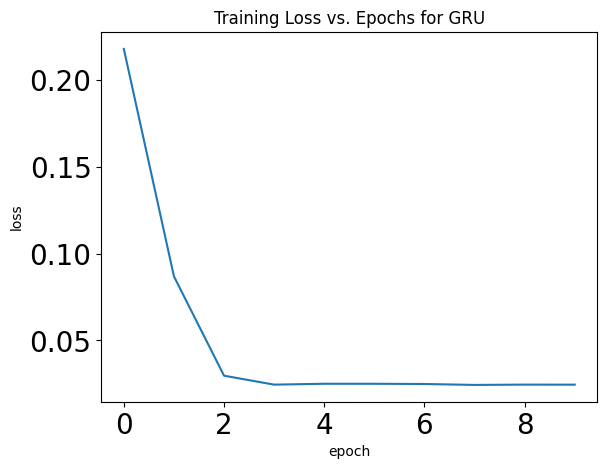

In [53]:
gru_model.compile(optimizer="adam",loss=loss)
gru_epochs = gru_model.fit(X_train, y_train, epochs=epochs,
                           batch_size=batch_size)
plot_training_loss(gru_epochs, "GRU")

## Evaluate GRU model using MAE, RMSE, and R^2.

In [54]:
print("GRU Predictions for Training Set")
gru_pred_train = gru_model.predict(X_train)
print("GRU Predictions for Testing Set")
gru_pred_test = gru_model.predict(X_test)
gru_mae = mean_absolute_error(y_test,gru_pred_test)
print("MAE of GRU model = ",gru_mae)
gru_rmse =  mean_squared_error(y_test,gru_pred_test) ** 0.5
print("RMSE of GRU model = ",gru_rmse)
#gru_r2_score = r2_score(y_test, gru_pred_test)
#print("R^2 Score of GRU model = ",gru_r2_score)
gru_mape_score = 100*mean_absolute_percentage_error(y_test, gru_pred_test)
print("MAPE Score of GRU model = {0} %".format(gru_mape_score))

GRU Predictions for Training Set
568/568 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
GRU Predictions for Testing Set
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
MAE of GRU model =  0.01916339260223934
RMSE of GRU model =  0.02503492498419659
MAPE Score of GRU model = 3.632804406405209 %


## Reverse transform scaler to convert to real values.

In [55]:
y_train_inverse = scaler.inverse_transform(y_train.reshape(-1, 1))
gru_pred_inv_train = scaler.inverse_transform(gru_pred_train)
y_test_inverse = scaler.inverse_transform(y_test.reshape(-1, 1))
gru_pred_inv_test = scaler.inverse_transform(gru_pred_test)

# Get values after inverse transformation
y_train_inverse = y_train_inverse.flatten()
gru_pred_inv_train = gru_pred_inv_train.flatten()
y_test_inverse = y_test_inverse.flatten()
gru_pred_inv_test = gru_pred_inv_test.flatten()

## Showing Actual y and Predicted y values as Dataframes.

### With Training Dates.

In [56]:
results_GRU_train = pd.DataFrame({"Date":first_6169_index_dates,
                            'Actual': y_train_inverse,
                            'Predicted': gru_pred_inv_train})
results_GRU_train

,Date,Actual,Predicted
0,2013-12-02 21:15:00,81.767178,81.471107
1,2013-12-02 21:20:00,81.259781,81.569656
2,2013-12-02 21:25:00,80.302937,81.630508
3,2013-12-02 21:30:00,81.114590,81.247643
4,2013-12-02 21:35:00,81.748109,81.199142
...,...,...,...
18151,2014-02-03 20:50:00,97.634226,95.643150
18152,2014-02-03 20:55:00,96.482168,95.621315
18153,2014-02-03 21:00:00,97.357795,95.247925
18154,2014-02-03 21:05:00,97.896059,95.236511


### With Testing Dates.

In [57]:
results_GRU_test = pd.DataFrame({"Date":last_6169_index_dates,
                            'Actual': y_test_inverse,
                            'Predicted': gru_pred_inv_test})
results_GRU_test

,Date,Actual,Predicted
0,2014-02-03 22:55:00,96.931048,95.590385
1,2014-02-03 23:00:00,97.525968,95.412140
2,2014-02-03 23:05:00,95.959969,95.486504
3,2014-02-03 23:10:00,96.169317,95.006409
4,2014-02-03 23:15:00,96.886848,94.609116
...,...,...,...
4514,2014-02-19 15:05:00,98.185415,95.957008
4515,2014-02-19 15:10:00,97.804168,96.121628
4516,2014-02-19 15:15:00,97.135468,96.138069
4517,2014-02-19 15:20:00,98.056852,95.819862


## Plotting Predictions for AEP_MW made by GRU Model.

### Testing Data Only.

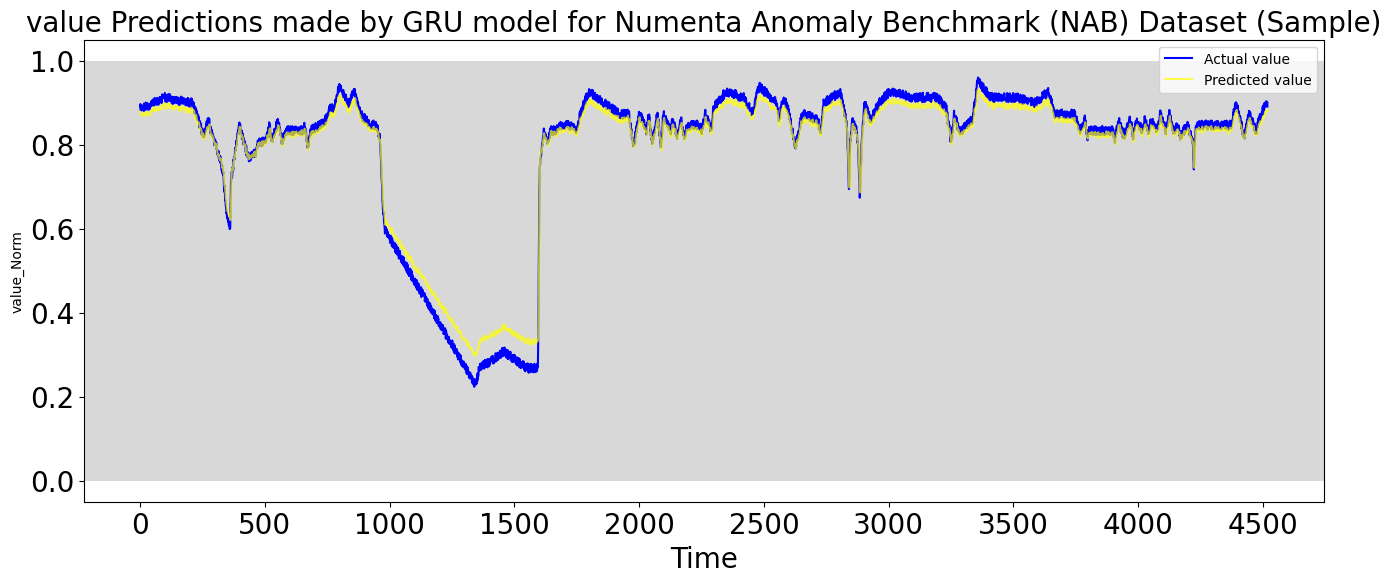

In [58]:
plt.figure(figsize=(16,6))
plt.plot(y_test, color='blue',label='Actual {0}'.format(feature))
plt.plot(gru_pred_test, alpha=0.7, color='yellow',
         label='Predicted {0}'.format(feature))
plt.axhspan(0, 1, facecolor='gray', alpha=0.3)
plt.title("{0} Predictions made by GRU model for {1}".
          format(feature, title_name), fontsize = 20)
plt.locator_params(axis='x', nbins=10)
plt.locator_params(axis='y', nbins=10)
#plt.ylim([40, 70])
plt.xlabel('Time', fontsize = 20)
plt.ylabel(feature_norm, fontsize = 10)
plt.legend()
plt.show()

### Training and Test Data Combined.

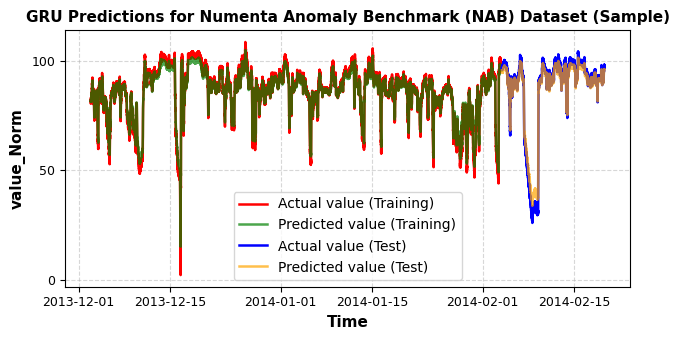

In [59]:
# 🔹 Create figure sized for IEEE 2-column layout
plt.figure(figsize=(6.5, 3.5))  # 6.5in width fits one column in IEEE

# 🔹 Plot training data
plt.plot(results_GRU_train['Date'], results_GRU_train['Actual'], color='red',
         label=f'Actual {feature} (Training)', linewidth=1.8)
plt.plot(results_GRU_train['Date'], results_GRU_train['Predicted'], color='green',
         label=f'Predicted {feature} (Training)', alpha=0.7, linewidth=1.8)

# 🔹 Plot test data
plt.plot(results_GRU_test['Date'], results_GRU_test['Actual'], color='blue',
         label=f'Actual {feature} (Test)', linewidth=1.8)
plt.plot(results_GRU_test['Date'], results_GRU_test['Predicted'], color='orange',
         label=f'Predicted {feature} (Test)', alpha=0.7, linewidth=1.8)

# 🔹 Formatting
plt.title(f'GRU Predictions for {title_name}', fontsize=11, fontweight='bold')
plt.xlabel('Time', fontsize=11, fontweight='bold')
plt.ylabel(feature_norm, fontsize=11,fontweight='bold')
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
plt.legend(fontsize=10, loc='best')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

# 🔹 Export for Appendix
plt.show()

## Combine Actual and Predicted Results for Train and Test Cases for GRU.

In [60]:
results_GRU = [results_GRU_train, results_GRU_test]
results_GRU = pd.concat(results_GRU)
display(results_GRU)

,Date,Actual,Predicted
0,2013-12-02 21:15:00,81.767178,81.471107
1,2013-12-02 21:20:00,81.259781,81.569656
2,2013-12-02 21:25:00,80.302937,81.630508
3,2013-12-02 21:30:00,81.114590,81.247643
4,2013-12-02 21:35:00,81.748109,81.199142
...,...,...,...
4514,2014-02-19 15:05:00,98.185415,95.957008
4515,2014-02-19 15:10:00,97.804168,96.121628
4516,2014-02-19 15:15:00,97.135468,96.138069
4517,2014-02-19 15:20:00,98.056852,95.819862


## Plotting Residuals for Actual and Predicted Results for GRU.

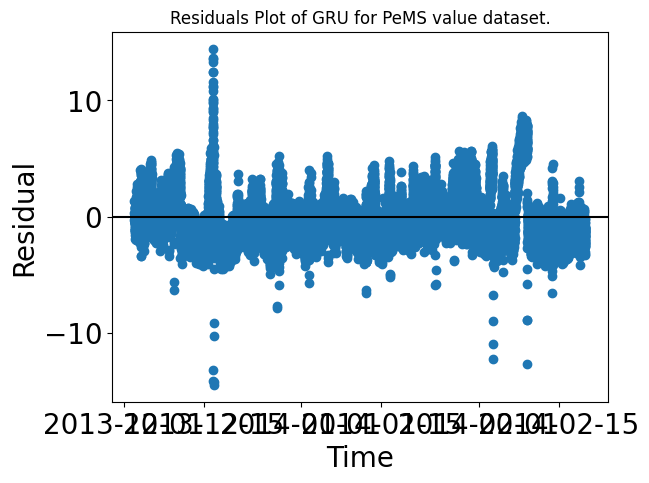

In [61]:
# Plotting Residuals for Actual and Predicted Results for GRU.
actual_arr_GRU = np.array(results_GRU['Actual'])
predicted_arr_GRU = np.array(results_GRU['Predicted'])
residuals_GRU = predicted_arr_GRU - actual_arr_GRU
plt.scatter(results_GRU['Date'], residuals_GRU)
plt.axhline(y=0, color = 'black')
plt.title("Residuals Plot of GRU for PeMS {} dataset.".format(feature_field))
#plt.locator_params(axis='x', nbins=10)
#plt.locator_params(axis='y', nbins=10)
#plt.ylim([40, 70])
plt.xlabel("Time", fontsize = 20)
plt.ylabel("Residual", fontsize = 20)
plt.show()

From the residual plots for the GRU model, it can be concluded that the GRU model is a good fit.

## Energy Consumption

In [62]:
measure_time_and_energy(gru_model, X_test)

Measuring inference time and estimating energy on CPU...
Model CPU inference time: 0.4322 seconds
Estimated CPU energy consumption (using general power value): 34.5752 Joules

Measuring inference time and estimating energy on GPU...
Estimated GPU inference time: 0.3747 seconds
Estimated GPU energy consumption (using general power value): 24.3547 Joules
ann_energy_per_sample 5389.39 µJ
Total GPU Energy: 24354667.69 uJ

Estimating FLOPs manually...
Estimated Total FLOPs (manual): 0


0.005389393154143443

# CNN (Conv1D) model

### Create CNN Model.

In [63]:
cnn_model = Sequential()

cnn_model.add(Conv1D(filters=8, kernel_size=3, activation=activation,
                     input_shape=(20,1)))
cnn_model.add(MaxPooling1D(pool_size=2))

cnn_model.add(Conv1D(filters=8, kernel_size=3, activation=activation,
                     input_shape=(20,1)))
cnn_model.add(MaxPooling1D(pool_size=2))

cnn_model.add(Flatten())
cnn_model.add(Dense(16, activation=activation))
cnn_model.add(Dropout(0.5))
cnn_model.add(Dense(1))
cnn_model.compile(optimizer='adam', loss='mse')
cnn_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 18, 8)          │            32 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 9, 8)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 7, 8)           │           200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 3, 8)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 24)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 649 (2.54 KB)

 Trainable params: 649 (2.54 KB)

 Non-trainable params: 0 (0.00 B)

### Train CNN model.

Epoch 1/10
568/568 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 0.1449
Epoch 2/10
568/568 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0675
Epoch 3/10
568/568 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0302
Epoch 4/10
568/568 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0232
Epoch 5/10
568/568 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0226
Epoch 6/10
568/568 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0215
Epoch 7/10
568/568 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0212
Epoch 8/10
568/568 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0209
Epoch 9/10
568/568 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0213
Epoch 10/10
568/568 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0209


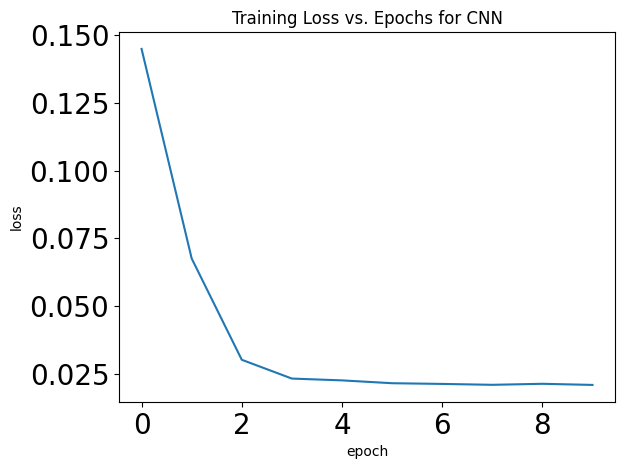

In [64]:
cnn_model.compile(optimizer="adam",loss=loss)
cnn_epochs = cnn_model.fit(X_train, y_train, epochs=epochs,
                           batch_size=batch_size)
plot_training_loss(cnn_epochs, "CNN")

### Evaluate CNN model using MAE, RMSE, and R^2.

In [65]:
print("CNN Predictions for Training Set")
cnn_pred_train = cnn_model.predict(X_train)
print("CNN Predictions for Testing Set")
cnn_pred_test = cnn_model.predict(X_test)
cnn_mae = mean_absolute_error(y_test,cnn_pred_test)
print("MAE of CNN model = ",cnn_mae)
cnn_rmse =  mean_squared_error(y_test,cnn_pred_test) ** 0.5
print("RMSE of CNN model = ",cnn_rmse)
#cnn_r2_score = r2_score(y_test, cnn_pred_test)
#print("R^2 Score of CNN model = ",cnn_r2_score)
cnn_mape_score = 100*mean_absolute_percentage_error(y_test, cnn_pred_test)
print("MAPE Score of CNN model = {0} %".format(cnn_mape_score))

CNN Predictions for Training Set
568/568 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
CNN Predictions for Testing Set
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
MAE of CNN model =  0.014826999788231448
RMSE of CNN model =  0.021453994868172132
MAPE Score of CNN model = 2.7868918524108235 %


### Reverse transform scaler to convert to real values.

In [66]:
y_train_inverse = scaler.inverse_transform(y_train.reshape(-1, 1))
cnn_pred_inv_train = scaler.inverse_transform(cnn_pred_train)
y_test_inverse = scaler.inverse_transform(y_test.reshape(-1, 1))
cnn_pred_inv_test = scaler.inverse_transform(cnn_pred_test)

# Get values after inverse transformation
y_train_inverse = y_train_inverse.flatten()
cnn_pred_inv_train = cnn_pred_inv_train.flatten()
y_test_inverse = y_test_inverse.flatten()
cnn_pred_inv_test = cnn_pred_inv_test.flatten()

### Showing Actual y and Predicted y values as Dataframes.

#### With Training Dates.

In [67]:
results_CNN_train = pd.DataFrame({"Date":first_6169_index_dates,
                                 'Actual': y_train_inverse,
                                 'Predicted': cnn_pred_inv_train})
results_CNN_train

,Date,Actual,Predicted
0,2013-12-02 21:15:00,81.767178,82.640388
1,2013-12-02 21:20:00,81.259781,82.414223
2,2013-12-02 21:25:00,80.302937,82.982498
3,2013-12-02 21:30:00,81.114590,82.721100
4,2013-12-02 21:35:00,81.748109,82.583588
...,...,...,...
18151,2014-02-03 20:50:00,97.634226,98.235817
18152,2014-02-03 20:55:00,96.482168,97.898201
18153,2014-02-03 21:00:00,97.357795,97.898415
18154,2014-02-03 21:05:00,97.896059,97.634201


#### With Testing Dates.

In [68]:
results_CNN_test = pd.DataFrame({"Date":last_6169_index_dates,
                                 'Actual': y_test_inverse,
                                 'Predicted': cnn_pred_inv_test})
results_CNN_test

,Date,Actual,Predicted
0,2014-02-03 22:55:00,96.931048,97.386505
1,2014-02-03 23:00:00,97.525968,97.666481
2,2014-02-03 23:05:00,95.959969,97.958549
3,2014-02-03 23:10:00,96.169317,97.598053
4,2014-02-03 23:15:00,96.886848,97.997673
...,...,...,...
4514,2014-02-19 15:05:00,98.185415,97.737228
4515,2014-02-19 15:10:00,97.804168,98.287941
4516,2014-02-19 15:15:00,97.135468,98.211624
4517,2014-02-19 15:20:00,98.056852,98.597198


### Plotting Predictions for AEP_MW made by CNN Model.

#### Only Testing Data.

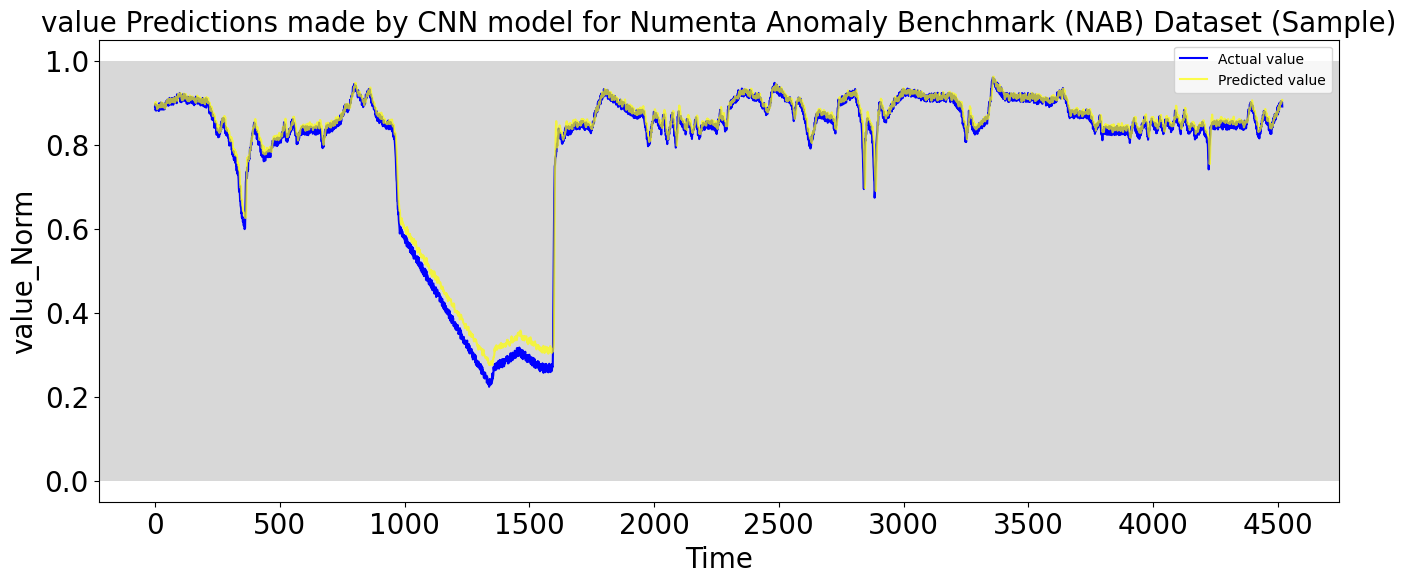

In [69]:
plt.figure(figsize=(16,6))
plt.plot(y_test, color='blue',label='Actual {0}'.format(feature))
plt.plot(cnn_pred_test, alpha=0.7, color='yellow',
         label='Predicted {0}'.format(feature))
plt.axhspan(0, 1, facecolor='gray', alpha=0.3)
plt.title("{0} Predictions made by CNN model for {1}".
          format(feature, title_name), fontsize = 20)
plt.locator_params(axis='x', nbins=10)
plt.locator_params(axis='y', nbins=10)
#plt.ylim([40, 70])
plt.xlabel('Time', fontsize = 20)
plt.ylabel(feature_norm, fontsize = 20)
plt.legend()
plt.show()

#### Training and Test Data Combined.

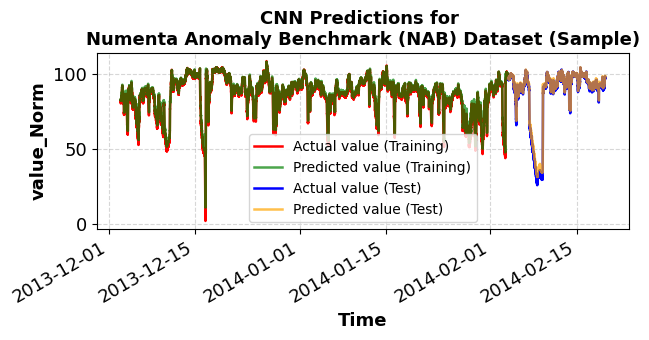

In [70]:
# Create figure sized for IEEE 2-column layout
#plt.figure(figsize=(6.5, 3.5))  # 6.5in width fits one column in IEEE
fig = plt.figure(figsize=(6.5, 3.5))  # capture the figure

# Plot training data
plt.plot(results_CNN_train['Date'], results_CNN_train['Actual'], color='red',
         label=f'Actual {feature} (Training)', linewidth=1.8)
plt.plot(results_CNN_train['Date'], results_CNN_train['Predicted'], color='green',
         label=f'Predicted {feature} (Training)', alpha=0.7, linewidth=1.8)

# Plot test data
plt.plot(results_CNN_test['Date'], results_CNN_test['Actual'], color='blue',
         label=f'Actual {feature} (Test)', linewidth=1.8)
plt.plot(results_CNN_test['Date'], results_CNN_test['Predicted'], color='orange',
         label=f'Predicted {feature} (Test)', alpha=0.7, linewidth=1.8)

# Formatting
plt.title("CNN Predictions for \n" + title_name, fontsize=13, fontweight='bold')
plt.xlabel('Time', fontsize = 13, fontweight='bold')
plt.ylabel(feature_norm, fontsize = 13, fontweight='bold')
#plt.locator_params(axis='x', nbins=5)
#plt.locator_params(axis='y', nbins=10)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.legend(fontsize=10, loc='best')
plt.grid(True, linestyle='--', alpha=0.5)
fig.autofmt_xdate()    # Auto-fix overlapping date labels
plt.tight_layout()
# Export for Appendix
plt.show()

### Combine Actual and Predicted Results for Train and Test Cases for CNN.

In [71]:
results_CNN = [results_CNN_train, results_CNN_test]
results_CNN = pd.concat(results_CNN)
display(results_CNN)

,Date,Actual,Predicted
0,2013-12-02 21:15:00,81.767178,82.640388
1,2013-12-02 21:20:00,81.259781,82.414223
2,2013-12-02 21:25:00,80.302937,82.982498
3,2013-12-02 21:30:00,81.114590,82.721100
4,2013-12-02 21:35:00,81.748109,82.583588
...,...,...,...
4514,2014-02-19 15:05:00,98.185415,97.737228
4515,2014-02-19 15:10:00,97.804168,98.287941
4516,2014-02-19 15:15:00,97.135468,98.211624
4517,2014-02-19 15:20:00,98.056852,98.597198


### Plotting Residuals for Actual and Predicted Results for CNN.

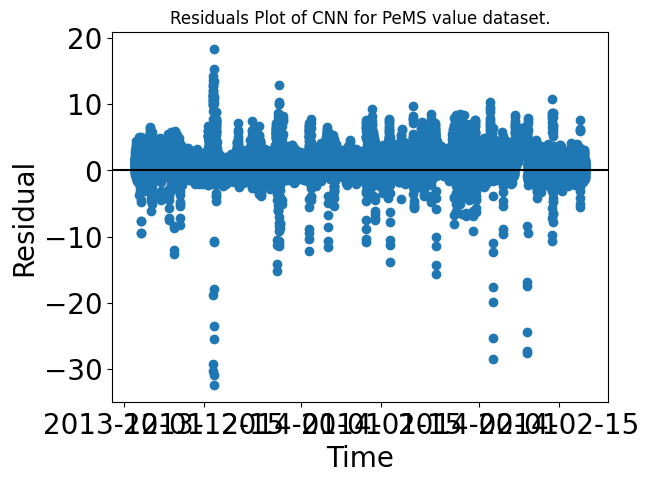

In [72]:
actual_arr_CNN = np.array(results_CNN['Actual'])
predicted_arr_CNN = np.array(results_CNN['Predicted'])
residuals_CNN = predicted_arr_CNN - actual_arr_CNN
plt.scatter(results_CNN['Date'], residuals_CNN)
plt.axhline(y=0, color = 'black')
plt.title("Residuals Plot of CNN for PeMS {} dataset.".format(feature_field))
#plt.locator_params(axis='x', nbins=10)
#plt.locator_params(axis='y', nbins=10)
#plt.ylim([40, 70])
plt.xlabel("Time", fontsize = 20)
plt.ylabel("Residual", fontsize = 20)
plt.show()

From the residual plots for the CNN model, it can be concluded that the CNN model is a good fit.

### Energy Consumption

In [73]:
measure_time_and_energy(cnn_model, X_test)

Measuring inference time and estimating energy on CPU...
Model CPU inference time: 0.6570 seconds
Estimated CPU energy consumption (using general power value): 52.5577 Joules

Measuring inference time and estimating energy on GPU...
Estimated GPU inference time: 0.3432 seconds
Estimated GPU energy consumption (using general power value): 22.3097 Joules
ann_energy_per_sample 4936.87 µJ
Total GPU Energy: 22309702.70 uJ

Estimating FLOPs manually...
Estimated Total FLOPs (manual): 0


0.0049368671464508525

# CNN-LSTM (Hybrid DNN) Model

## Create CNN-LSTM Model

In [74]:
cnn_lstm_model = Sequential()

cnn_lstm_model.add(Conv1D(filters=8, kernel_size=3, activation=activation,
                          input_shape=(40,1)))
cnn_lstm_model.add(MaxPooling1D(pool_size=2))

cnn_lstm_model.add(LSTM(8,activation=activation,return_sequences=False))
cnn_lstm_model.add(Dropout(0.1))

cnn_lstm_model.add(Dense(1))
cnn_lstm_model.compile(optimizer='adam', loss='mse')
cnn_lstm_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 38, 8)          │            32 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 19, 8)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 8)              │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 585 (2.29 KB)

 Trainable params: 585 (2.29 KB)

 Non-trainable params: 0 (0.00 B)

## Train CNN-LSTM Model

Epoch 1/10
568/568 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.1296
Epoch 2/10
568/568 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0607
Epoch 3/10
568/568 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0458
Epoch 4/10
568/568 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0337
Epoch 5/10
568/568 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.0239
Epoch 6/10
568/568 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0180
Epoch 7/10
568/568 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0150
Epoch 8/10
568/568 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0138
Epoch 9/10
568/568 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.0129
Epoch 10/10
568/568 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0126


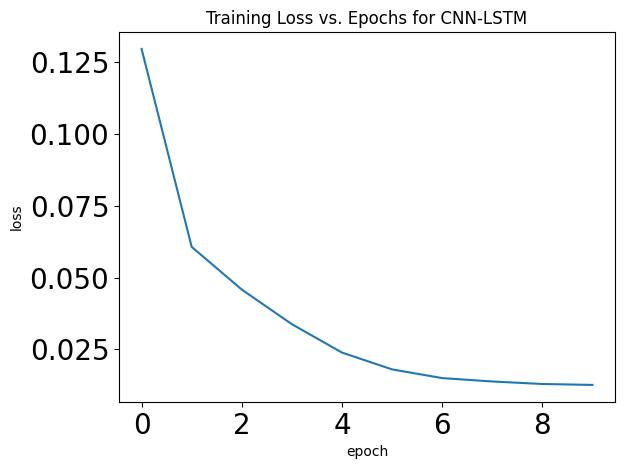

In [75]:
cnn_lstm_model.compile(optimizer="adam",loss=loss)
cnn_lstm_epochs = cnn_lstm_model.fit(X_train, y_train, epochs=epochs,
                                     batch_size=batch_size)
plot_training_loss(cnn_lstm_epochs, "CNN-LSTM")

## Evaluate CNN-LSTM Model using MAE, RMSE, and R2.

In [76]:
print("CNN-LSTM Predictions for Training Set")
cnn_lstm_pred_train = cnn_lstm_model.predict(X_train)
print("CNN-LSTM Predictions for Testing Set")
cnn_lstm_pred_test = cnn_lstm_model.predict(X_test)
cnn_lstm_mae = mean_absolute_error(y_test,cnn_lstm_pred_test)
print("MAE of CNN-LSTM model = ",cnn_lstm_mae)
cnn_lstm_rmse =  mean_squared_error(y_test,cnn_lstm_pred_test) ** 0.5
print("RMSE of CNN-LSTM model = ",cnn_lstm_rmse)
cnn_lstm_r2_score = r2_score(y_test, cnn_lstm_pred_test)
print("R^2 Score of CNN-LSTM model = ",cnn_lstm_r2_score)
cnn_lstm_mape_score = 100*mean_absolute_percentage_error(y_test,
                                                         cnn_lstm_pred_test)
print("MAPE Score of CNN-LSTM model = {0} %".format(cnn_lstm_mape_score))

CNN-LSTM Predictions for Training Set
568/568 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
CNN-LSTM Predictions for Testing Set
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
MAE of CNN-LSTM model =  0.01059841773329788
RMSE of CNN-LSTM model =  0.016056245469326203
R^2 Score of CNN-LSTM model =  0.9922877858030495
MAPE Score of CNN-LSTM model = 2.09032431874194 %


## Reverse Transform Scaler to Convert to Real Values.

In [77]:
y_train_inverse = scaler.inverse_transform(y_train.reshape(-1, 1))
cnn_lstm_pred_inv_train = scaler.inverse_transform(cnn_lstm_pred_train)
y_test_inverse = scaler.inverse_transform(y_test.reshape(-1, 1))
cnn_lstm_pred_inv_test = scaler.inverse_transform(cnn_lstm_pred_test)

# Get values after inverse transformation.
y_train_inverse = y_train_inverse.flatten()
cnn_lstm_pred_inv_train = cnn_lstm_pred_inv_train.flatten()
y_test_inverse = y_test_inverse.flatten()
cnn_lstm_pred_inv_test = cnn_lstm_pred_inv_test.flatten()

## Showing Actual y and Predicted y values as Dataframes.

In [78]:
results_CNN_LSTM_train = pd.DataFrame({"Date":first_6169_index_dates,
                                 'Actual': y_train_inverse,
                                 'Predicted': cnn_lstm_pred_inv_train})
results_CNN_LSTM_train

,Date,Actual,Predicted
0,2013-12-02 21:15:00,81.767178,81.427032
1,2013-12-02 21:20:00,81.259781,81.796364
2,2013-12-02 21:25:00,80.302937,81.841080
3,2013-12-02 21:30:00,81.114590,81.445976
4,2013-12-02 21:35:00,81.748109,81.545860
...,...,...,...
18151,2014-02-03 20:50:00,97.634226,97.337364
18152,2014-02-03 20:55:00,96.482168,97.489761
18153,2014-02-03 21:00:00,97.357795,97.128380
18154,2014-02-03 21:05:00,97.896059,97.207275


In [79]:
# Now let's see our actual y and predicted y values as dataframes
results_CNN_LSTM_test = pd.DataFrame({"Date":last_6169_index_dates,
                                 'Actual': y_test_inverse,
                                 'Predicted': cnn_lstm_pred_inv_test})
results_CNN_LSTM_test

,Date,Actual,Predicted
0,2014-02-03 22:55:00,96.931048,97.201851
1,2014-02-03 23:00:00,97.525968,97.005653
2,2014-02-03 23:05:00,95.959969,97.038231
3,2014-02-03 23:10:00,96.169317,96.766998
4,2014-02-03 23:15:00,96.886848,96.418152
...,...,...,...
4514,2014-02-19 15:05:00,98.185415,97.490082
4515,2014-02-19 15:10:00,97.804168,97.836487
4516,2014-02-19 15:15:00,97.135468,97.876701
4517,2014-02-19 15:20:00,98.056852,97.631157


## Plotting Predictions for Monthly Mean Sunspot Number made by CNN-LSTM Model.

#### Only Testing Data.

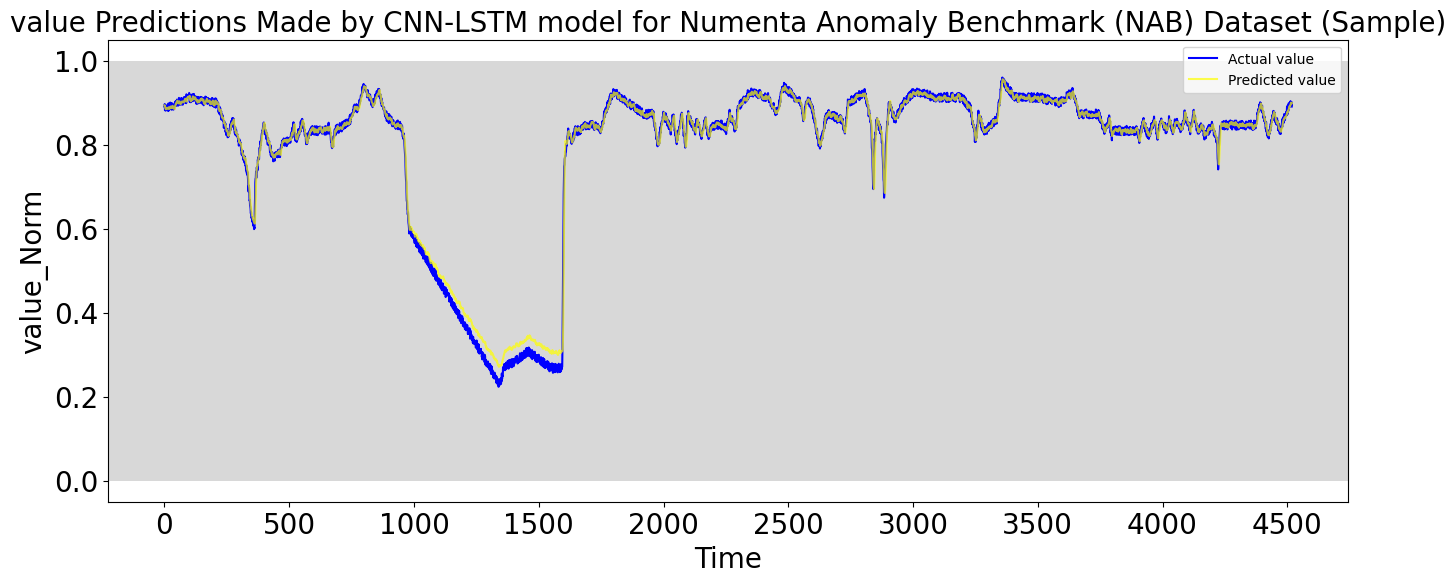

In [80]:
plt.figure(figsize=(16,6))
plt.plot(y_test, color='blue',label='Actual {0}'.format(feature))
plt.plot(cnn_lstm_pred_test, alpha=0.7, color='yellow', \
         label='Predicted {0}'.format(feature))
plt.axhspan(0, 1, facecolor='gray', alpha=0.3)
plt.title("{0} Predictions Made by CNN-LSTM model for {1}".
          format(feature, title_name), fontsize = 20)
plt.locator_params(axis='x', nbins=10)
plt.locator_params(axis='y', nbins=10)
#plt.ylim([40, 70])
plt.xlabel('Time', fontsize = 20)
plt.ylabel(feature_norm, fontsize = 20)
plt.legend()
plt.show()

#### Training and Test Data Combined.

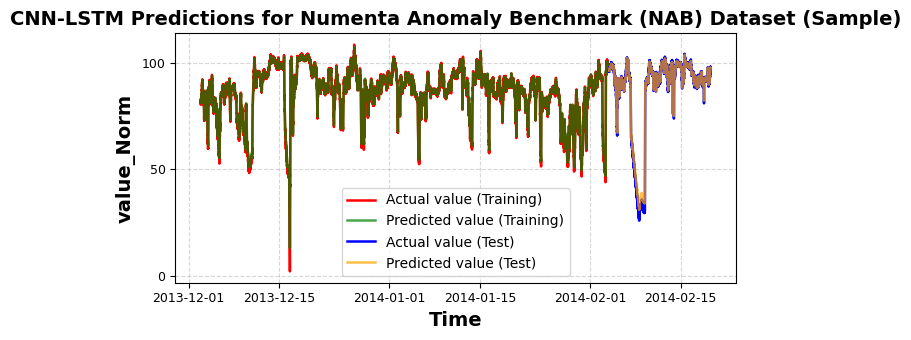

In [81]:
# 🔹 Create figure sized for IEEE 2-column layout
plt.figure(figsize=(6.5, 3.5))  # 6.5in width fits one column in IEEE

# 🔹 Plot training data
plt.plot(results_CNN_LSTM_train['Date'], results_CNN_LSTM_train['Actual'],
         color='red', label=f'Actual {feature} (Training)', linewidth=1.8)
plt.plot(results_CNN_LSTM_train['Date'], results_CNN_LSTM_train['Predicted'],
         color='green', label=f'Predicted {feature} (Training)', alpha=0.7,
         linewidth=1.8)

# 🔹 Plot test data
plt.plot(results_CNN_LSTM_test['Date'], results_CNN_LSTM_test['Actual'],
         color='blue', label=f'Actual {feature} (Test)', linewidth=1.8)
plt.plot(results_CNN_LSTM_test['Date'], results_CNN_LSTM_test['Predicted'],
         color='orange', label=f'Predicted {feature} (Test)', alpha=0.7,
         linewidth=1.8)

# 🔹 Formatting
plt.title(f'CNN-LSTM Predictions for {title_name}', fontsize=14,
          fontweight='bold')
plt.xlabel('Time', fontsize=14, fontweight='bold')
plt.ylabel(feature_norm, fontsize=14, fontweight='bold')
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
plt.legend(fontsize=10, loc='best')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

# 🔹 Export for Appendix
plt.show()

## Combine Actual and Predicted Results for Train and Test Cases for CNN-LSTM.

In [82]:
results_CNN_LSTM = [results_CNN_LSTM_train, results_CNN_LSTM_test]
results_CNN_LSTM = pd.concat(results_CNN_LSTM)
display(results_CNN_LSTM)

,Date,Actual,Predicted
0,2013-12-02 21:15:00,81.767178,81.427032
1,2013-12-02 21:20:00,81.259781,81.796364
2,2013-12-02 21:25:00,80.302937,81.841080
3,2013-12-02 21:30:00,81.114590,81.445976
4,2013-12-02 21:35:00,81.748109,81.545860
...,...,...,...
4514,2014-02-19 15:05:00,98.185415,97.490082
4515,2014-02-19 15:10:00,97.804168,97.836487
4516,2014-02-19 15:15:00,97.135468,97.876701
4517,2014-02-19 15:20:00,98.056852,97.631157


## Plotting Residuals for Actual and Predicted Results for CNN-LSTM.

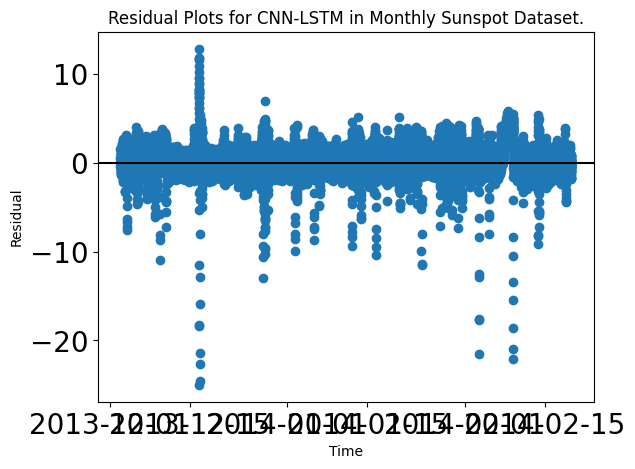

In [83]:
actual_arr_CNN_LSTM = np.array(results_CNN_LSTM['Actual'])
predicted_arr_CNN_LSTM = np.array(results_CNN_LSTM['Predicted'])
residuals_CNN_LSTM = predicted_arr_CNN_LSTM - actual_arr_CNN_LSTM
plt.scatter(results_CNN_LSTM['Date'], residuals_CNN_LSTM)
plt.axhline(y=0, color = 'black')
plt.title("Residual Plots for CNN-LSTM in Monthly Sunspot Dataset.")
#plt.locator_params(axis='x', nbins=10)
#plt.locator_params(axis='y', nbins=10)
#plt.ylim([40, 70])
plt.xlabel("Time")
plt.ylabel("Residual")
plt.show()

## Energy Consumption

In [84]:
measure_time_and_energy(cnn_lstm_model, X_test)

Measuring inference time and estimating energy on CPU...
Model CPU inference time: 0.4858 seconds
Estimated CPU energy consumption (using general power value): 38.8657 Joules

Measuring inference time and estimating energy on GPU...
Estimated GPU inference time: 0.5780 seconds
Estimated GPU energy consumption (using general power value): 37.5679 Joules
ann_energy_per_sample 8313.31 µJ
Total GPU Energy: 37567850.41 uJ

Estimating FLOPs manually...
Estimated Total FLOPs (manual): 0


0.008313310544663336

# Forecasting Future Data for all models

## Essential Functions.

In [85]:
# this section for unknown future.
future=20
#future=seq_len
forecast_LSTM = []
forecast_DSNN = []
forecast_CNN_LSTM = []

In [86]:
def insert_end(Xin, new_input, timestep):
    for i in range(timestep-1):
        Xin[:,i,:] = Xin[:,i+1,:]
    Xin[:,timestep-1,:] = new_input
    return Xin

def forecast_data(Xin, model_type, forecast, future_num):
    time=[]
    data_pts = future_num
    for j in range(data_pts):
      out = model_type.predict(Xin, batch_size=1000)
      forecast.append(out[j, 0])
      Xin = insert_end(Xin, out[j, 0], future_num)
      time_current = pd.to_datetime(df_norm.index[-1])+timedelta(days=30*j)
      if (j % 100 == 0):
        print("j = {0}".format(j))
        print("forecast: {0}".format(forecast))
        print("time_current: ",  time_current)
      time.append(time_current)


    forcasted_output=np.asanyarray(forecast)
    forcasted_output=forcasted_output.reshape(-1,1)
    forcasted_output = scaler.inverse_transform(forcasted_output)
    forcasted_output = pd.DataFrame(forcasted_output)
    date = pd.DataFrame(time)
    forecast_result = pd.concat([date, forcasted_output],axis=1)
    forecast_result.columns = "Date","Forecasted"

    return forecast_result

In [87]:
# Plotting Predictions and Forecast for Monthly Mean Sunspot Number.
def plot_forecast(forecast_set, model_name, mode, min=140, max=165):
    plt.figure(figsize=(16,6))
    plt.plot(forecast_set['Date'], forecast_set['Forecasted'], alpha=0.7,
             color='teal', label='Forecasted {0}'.format(feature))
    plt.axhspan(0, 1, facecolor='gray', alpha=0.3)
    plt.title('{0} Forecast for {1} using {2}'.
              format(feature_field, mode, model_name), fontsize = 15,
              fontweight='bold')
    plt.locator_params(axis='x', nbins=10)
    plt.locator_params(axis='y', nbins=10)
    #plt.ylim([40, 70])
    plt.xlabel('Time', fontsize = 20, fontweight='bold')
    plt.ylabel(feature_field, fontsize = 20, fontweight='bold')
    plt.rc('xtick', labelsize=10)
    plt.rc('ytick', labelsize=10)
    plt.legend()
    plt.show()

In [88]:
# Plotting Predictions for Vehicle Hours/Miles.
def plot_with_forecast(train_set, test_set, forecast_set, model_name,
                       mode):
    plt.figure(figsize=(16,6))
    plt.plot(train_set['Date'], train_set['Actual'], color='red',
             label='Actual {0} (Training Case)'.format(feature))
    plt.plot(train_set['Date'], train_set['Predicted'], alpha=0.7,
             color='green',
             label='Predicted {0} (Training Case)'.format(feature))
    plt.plot(test_set['Date'], test_set['Actual'], color='blue',
            label='Actual {0} (Test Case)'.format(feature))
    plt.plot(test_set['Date'], test_set['Predicted'], alpha=0.7, color='yellow',
             label='Predicted {0} (Test Case)'.format(feature))
    plt.plot(forecast_set['Date'], forecast_set['Forecasted'], alpha=0.7,
             color='teal', label='Forecasted {0}'.format(feature))
    plt.axhspan(0, 1, facecolor='gray', alpha=0.3)
    plt.title("{0} Predictions and Forecasts made by {1} model for {2}".
              format(feature_field, model_name, title_name), fontsize = 15)
    plt.locator_params(axis='x', nbins=10)
    plt.locator_params(axis='y', nbins=10)
    plt.rc('xtick', labelsize=10)
    plt.rc('ytick', labelsize=10)
    #plt.ylim([1052, 1054])
    plt.xlabel('Time', fontsize = 15)
    plt.ylabel('Normalized {0} Scale'.format(feature_field), fontsize = 15)
    plt.legend()
    plt.show()

## Forecasting Future Data for LSTM.

In [89]:
Xin = X_test[:,:,:]
Xin

array([[[0.90820104],
        [0.89074345],
        [0.90915004],
        ...,
        [0.89520638],
        [0.90026402],
        [0.89311055]],

       [[0.89074345],
        [0.90915004],
        [0.89630184],
        ...,
        [0.90026402],
        [0.89311055],
        [0.89119657]],

       [[0.90915004],
        [0.89630184],
        [0.89647063],
        ...,
        [0.89311055],
        [0.89119657],
        [0.89678657]],

       ...,

       [[0.87824985],
        [0.86983175],
        [0.87659729],
        ...,
        [0.89523559],
        [0.90298287],
        [0.8994006 ]],

       [[0.86983175],
        [0.87659729],
        [0.89015836],
        ...,
        [0.90298287],
        [0.8994006 ],
        [0.89311734]],

       [[0.87659729],
        [0.89015836],
        [0.87212086],
        ...,
        [0.8994006 ],
        [0.89311734],
        [0.90177487]]])

In [90]:
#Xin_reshaped_LSTM = Xin.reshape(Xin.shape[0], Xin.shape[2], 1)
forecast_result_lstm = forecast_data(Xin, lstm_model, forecast_LSTM, future)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
j = 0
forecast: [np.float32(0.87736064)]
time_current:  2014-02-19 15:25:00
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


In [91]:
forecast_result_lstm

,Date,Forecasted
0,2014-02-19 15:25:00,95.458549
1,2014-03-21 15:25:00,95.189636
2,2014-04-20 15:25:00,94.904190
3,2014-05-20 15:25:00,94.230042
4,2014-06-19 15:25:00,93.621483
5,2014-07-19 15:25:00,93.172935
6,2014-08-18 15:25:00,92.629265
7,2014-09-17 15:25:00,92.160355
8,2014-10-17 15:25:00,91.663246
9,2014-11-16 15:25:00,91.105614


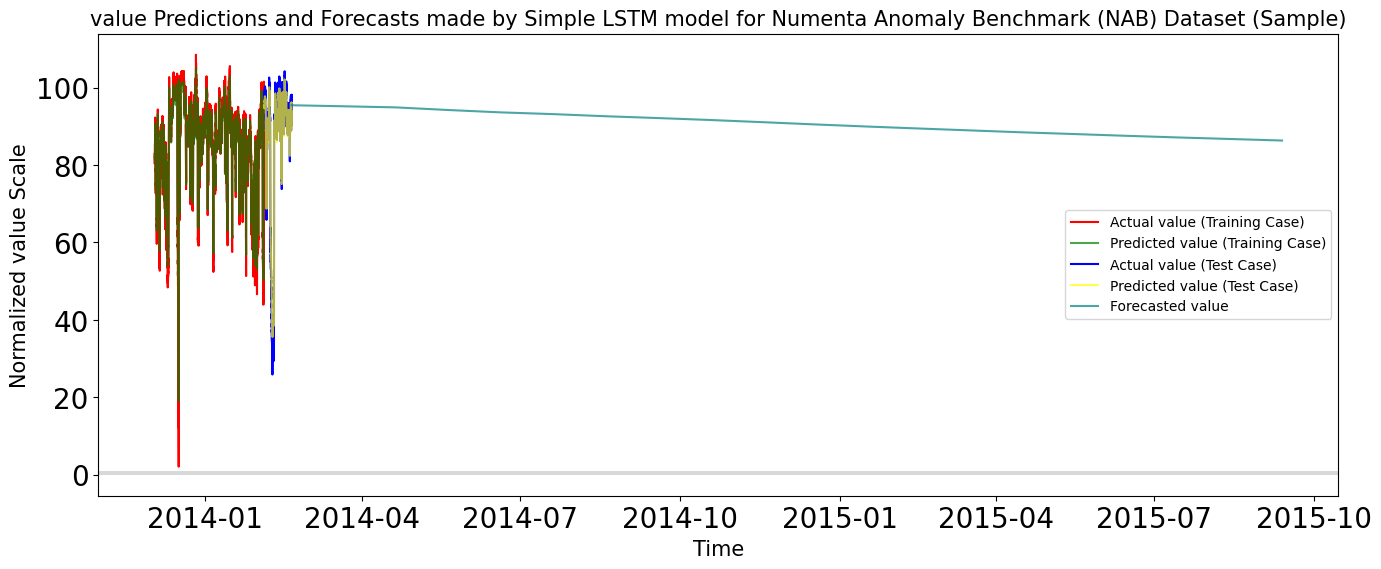

In [92]:
# Plot Forecast combined with Training and Testing Data.
plot_with_forecast(results_LSTM_train, results_LSTM_test, forecast_result_lstm,
                   'Simple LSTM', title_name)

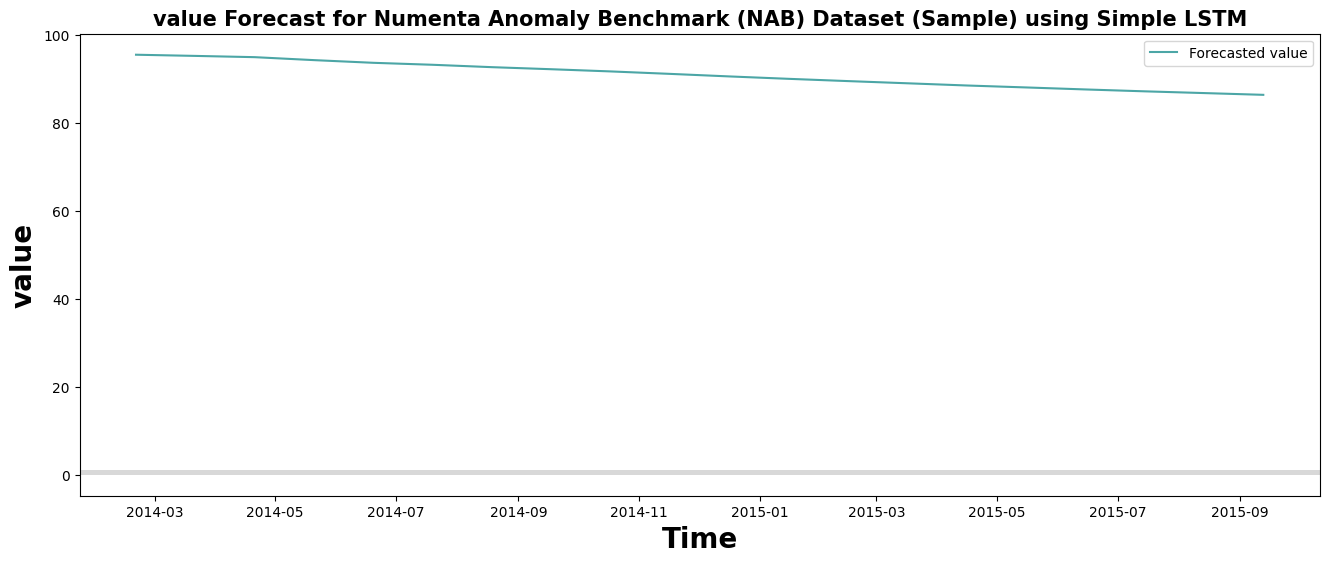

In [93]:
# Only Forecast Data for closer look.
plot_forecast(forecast_result_lstm, 'Simple LSTM', title_name)

## Forecasting Future Data for CNN-LSTM

In [94]:
forecast_result_cnn_lstm = forecast_data(Xin, cnn_lstm_model, forecast_CNN_LSTM,
                                         future)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
j = 0
forecast: [np.float32(0.79380304)]
time_current:  2014-02-19 15:25:00
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


In [95]:
forecast_result_cnn_lstm

,Date,Forecasted
0,2014-02-19 15:25:00,86.565857
1,2014-03-21 15:25:00,86.377457
2,2014-04-20 15:25:00,86.298447
3,2014-05-20 15:25:00,86.164192
4,2014-06-19 15:25:00,86.132965
5,2014-07-19 15:25:00,86.062355
6,2014-08-18 15:25:00,86.073242
7,2014-09-17 15:25:00,86.054352
8,2014-10-17 15:25:00,86.089897
9,2014-11-16 15:25:00,86.110001


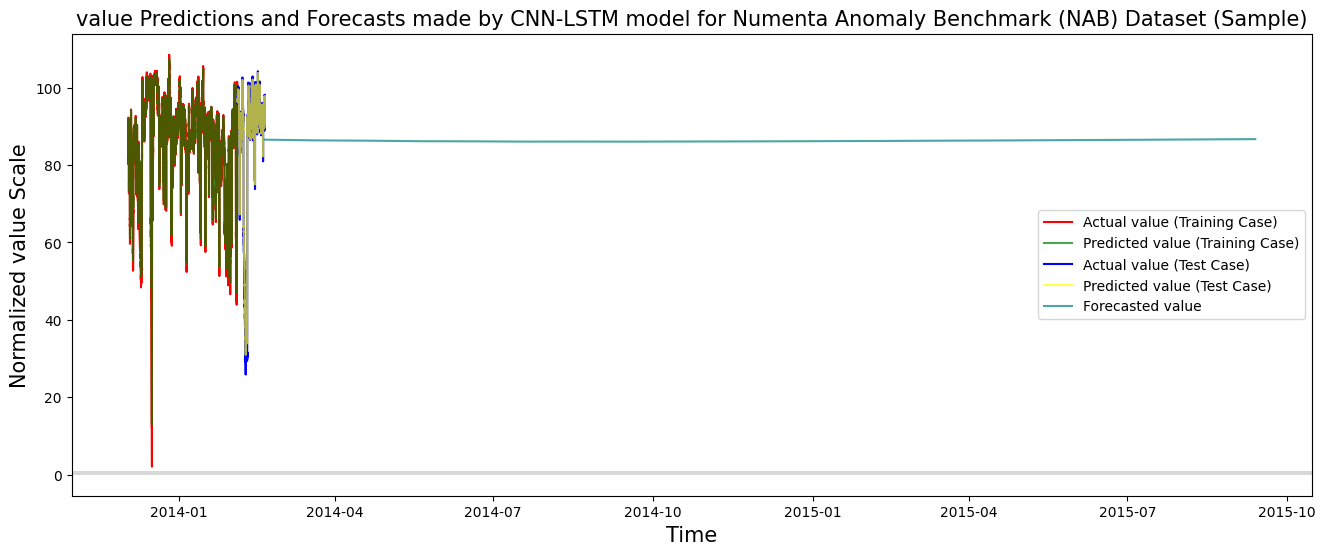

In [96]:
# Plot Forecast combined with Training and Testing Data.
plot_with_forecast(results_CNN_LSTM_train, results_CNN_LSTM_test,
                   forecast_result_cnn_lstm , 'CNN-LSTM', title_name)

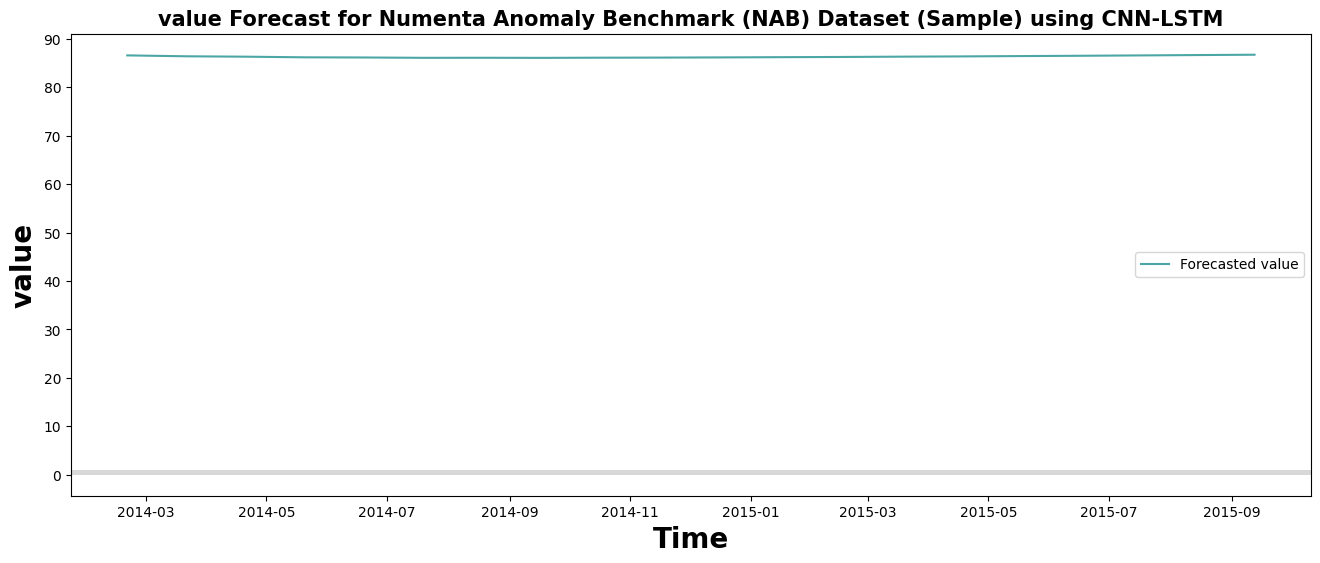

In [97]:
# Only Forecast Data for closer look.
plot_forecast(forecast_result_cnn_lstm, 'CNN-LSTM', title_name)

# Creating a pickle file for all classifier models.

## Mount model_pkl folder.

In [98]:
#os.chdir('/content/drive/My Drive/VT/Research/ap_datasets/model_pkl')

## Send model to pkl file.

In [99]:
#filename_lstm = 'TSC_sunset-prediction-lstm-model.pkl'
#pickle.dump(lstm_model, open(filename_lstm, 'wb'))